# 1. Data collection and preprocessing
This repository detailed the list of processing and analysis how to retrieve a continuous diurnal LST during peak summer months with high spatial resolution.

| Data                 | Data source     | Access / Download source                                               | Preprocessing | Reference                              |
|----------------------|-----------------|------------------------------------------------------------------------|---------------|----------------------------------------|
| Daytime and Nighttime – Coarse     | MODIS           | APPEEARS - https://appeears.earthdatacloud.nasa.gov/                   | OSGeo4W Shell | [Modis_preprocessing](preprocessing/modis.txt)     |
| 		       | Himawari SST    | WinSCP - https://winscp.net/eng/download.php                           | OSGeo4W Shell | [Himawari_preprocessing](preprocessing/himawari.txt)  |
| Daytime – Fine       | Landsat 8 and 9 | Google Earth Engine - GEE code (Ermida et al., 2020) https://github.com/sofiaermida/Landsat_SMW_LST                  | GEE | [Landsat_preprocessing](preprocessing/landsat.txt)   |
| Nighttime – Fine   | ECOSTRESS       | APPEEARS - https://appeears.earthdatacloud.nasa.gov/                   | ArcGIS - Spatial analyst | Mosaic and Raster calculator to convert Kelvin into Celcius |

# 2. Data description

In [2]:
import pandas as pd
# load the list of images
image_list = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\xlsx\list_of_images_csv.csv")

# Preview first 40 rows
display(image_list.head(40))

,spatial,temporal,use,date,view_time_UTC,view_time_AEDT,file_ID
0,Fine,Daytime,Base,7/01/2023,7/01/2023 0:04,7/01/2023 11:04,LC80920862023007LGN00
1,Fine,Daytime,Reference,8/01/2021,8/01/2021 0:10,8/01/2021 11:10,LC80930862021008LGN00
2,Fine,Daytime,Reference,19/01/2022,19/01/2022 0:10,19/01/2022 11:10,LC90930862022019LGN01
3,Fine,Daytime,Reference,20/01/2022,20/01/2022 0:04,20/01/2022 11:04,LC80920872022020LGN00
4,Fine,Nighttime,Base,25/12/2022,25/12/2022 12:50,25/12/2022 23:50,ECO_L2T_LSTE.002_LST_doy2022359124954_aid0001_55S
5,Fine,Nighttime,Base,25/12/2022,25/12/2022 12:50,25/12/2022 23:50,ECO_L2T_LSTE.002_LST_doy2022359125046_aid0001_55S
6,Fine,Nighttime,Reference,12/12/2021,12/12/2021 11:22,12/12/2021 22:22,ECO_L2T_LSTE.002_LST_doy2021346112222_aid0001_55S
7,Fine,Nighttime,Reference,9/02/2023,9/02/2023 12:50,9/02/2023 23:50,ECO_L2T_LSTE.002_LST_doy2023040114723_aid0001_55S
8,Coarse,Daytime,Base,7/01/2023,6/01/2023 22:48,7/01/2023 9:48,MOD11A1.061_LST_Day_1km_doy2023007000000_aid0001
9,Coarse,Daytime,Reference,8/01/2021,7/01/2021 23:54,8/01/2021 10:54,MOD11A1.061_LST_Day_1km_doy2021008000000_aid0001


# 2. Coarse images: Mosaicking, Reprojection, Resampling
The STARFM preprocessing steps are shown below

## 2.2 Daytime
The himawari image does not fully cover the Port Philip bay. Extrapolation using IDW was conducted. The original resolution was 2km. It was resampled to 1km to fit with the MODIS data. Then the SST in the study area is extracted using this file
C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\shapefile\ppb_square_b.7z

Extraction of the MODIS using a full rectangle with width and height values multiple by 1km (Unit of MODIS)
C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\shapefile\MODIS_fishnet_diss.7z

After alignment with the reference extract the output using
C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\shapefile\MODIS_extractByMask.7z

Resampling to 30 m (Reference fine = Landasat). 
Corresponding file to get the width and height (same extent as reference image), the following file was used
C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\shapefile\modis_30m_fish_diss_e.7z

## 2.3 Nightime
Resampling to 70 m (Reference fine = ECOSTRESS).
Corresponding file to get the width and height (same extent as reference image), the following file was used
...\shapefile\modis_70m_fishnet_20230209_diss.7z

The full preprocessing workflow is available at:
- [Daytime data processing](preprocessing/daytime_preprocessing.txt)
- [Nighttime data processing](preprocessing/nighttime_preprocessing.txt)

# 3. Spatiotemporal data fusion
## 3.1. STARFM
To run STARFM, the following repository was used (Mileva et al. 2018)
https://github.com/nmileva/starfm4py?tab=readme-ov-file

[STARFM parameters](preprocessing/starfm_parameters.txt) 

## 3.2. FSDAF
To run FSDAF, the following repository was used (Zhu et al., 2016)

The imput land cover classification is found in 
- For daytime: .../raw/fsdaf_classification/day_RF_classification_extract.tif
- For nighttime: .../raw/fsdaf_classification/night_RF_classification_extract.tif

The classification was run in Google Earth Engine (image on 14/01/2023)
https://code.earthengine.google.com/70404941027acb110eceaa87214e1f5e 

A winter classification was also conducted (image on 31/08/2022)
https://code.earthengine.google.com/2d39fb8fda1d8cc0efa7106107c28896 

# 4. Accuracy assessment
The following metrics were adopted from Zhu et al. (2022). Reference (observed) images were selected outside the analysis period (December 2022–February 2023) but within the same season in the nearest available years.
https://www.sciencedirect.com/science/article/pii/S003442572200116X?via%3Dihub#f0020 

Some reference images occasionally contain clouds. To address this, LST values were extracted only from cloud-free areas.

| Temporal   | Extraction      				      |
|------------|------------------------------------------------|
| Daytime    | …/shapefile/landsat_20220120_extract_fish.7z   |
| Nighttime  | …/shapefile/modis_70m_fishnet_20230209_diss.7z |

The nighttime reference raster contained no-data values, which were filled using the data-filling procedure described in [Data filling](preprocessing/reference_filling.txt).

## 4.1 Some scenes of observed and predicted LST

## 4.2 Accuracy assessment of Models
(Zhu et al., 2022).   
https://www.sciencedirect.com/science/article/pii/S003442572200116X?via%3Dihub#f0020 
https://github.com/XZhu-lab/Fusion-accuracy-assessment

markdown_table = """
| Method | 1st input | 2nd input | Observations |
|--------|-----------|-----------|--------------|
| STARFM | Fine reference image | Fused image | - |
| FSDAF | Fine reference image | Fused image | - |
| F0 | Fine reference image | Fine base image  | - |
| CP | Fine reference image | Coarse reference image | - |
| ATF | Fine reference image | Fine base + (Fine reference − Fine base) × scaling factor | ∆T: temporal change from base time (t₀) to prediction time (tₚ) |
| ASF | Fine reference image | Coarse reference + (Fine reference − Coarse Reference) × scaling factor | ∆S: spatial difference between fine and coarse images (spatial sharpness term) |

Although the fusion framework allows user-defined amplification of temporal and spatial terms, no additional scaling was applied in this study (scaling factor = 1.5) to preserve the physical realism of land surface temperature and avoid over-amplification of thermal contrasts.

Run raster caluclator to get [∆T and ∆S](preprocessing/deltaT_deltaS_raster_calculator.txt)

For visualisation using the Taylor Diagram, the code by (Zhu et al., 2022) has been modified as the points are visibles only for 6 methods, not for 2. 
[APA Taylor Diagram](preprocessing/apa_taylor_diagram.txt)


| Daytime: 08/01/2021 | Daytime: 19/01/2022 | Daytime: 20/01/2022 |
|---------|---------|---------|
| <a href="jpg/APA_day_20210108.jpg" target="_blank"><img src="jpg/APA_day_20210108.jpg" width="450"/></a> | <a href="jpg/APA_day_20220119.jpg" target="_blank"><img src="jpg/APA_day_20220119.jpg" width="450"/></a> | <a href="jpg/APA_day_20220120.jpg" target="_blank"><img src="jpg/APA_day_20220120.jpg" width="450"/></a> |

| Nighttime: 12/12/2021 | Nighttime: 09/02/2023 |
|-----------|-----------|
| <a href="jpg/APA_night_20211212.jpg" target="_blank"><img src="jpg/APA_night_20211212.jpg" width="450"/></a> | <a href="jpg/APA_night_20230209.jpg" target="_blank"><img src="jpg/APA_night_20230209.jpg" width="450"/></a> |



## 4.3 Structural similarity index (SSIM)

d_STARFM_20210108_ext.tif SSIM (Reference): 0.9445


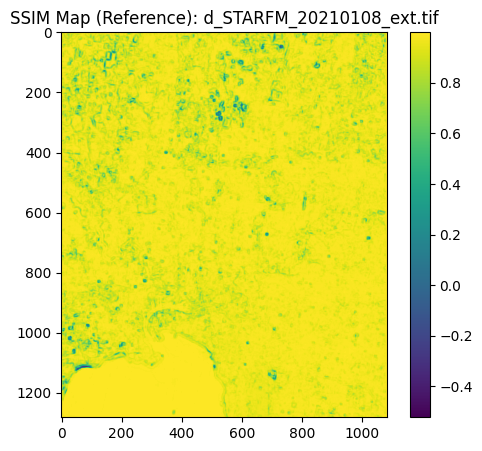

d_STARFM_20220119_ext.tif SSIM (Reference): 0.9348


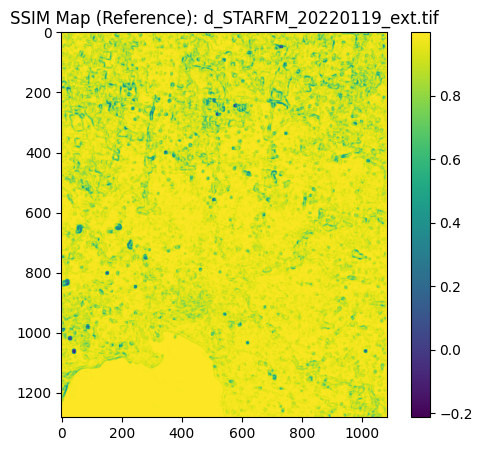

d_STARFM_20220120_ext.tif SSIM (Reference): 0.9417


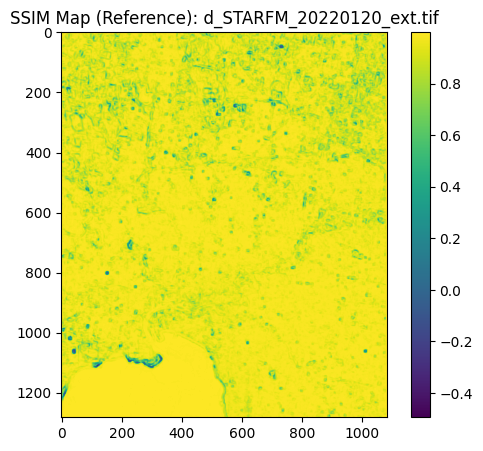

In [20]:
import numpy as np
import tifffile as tiff
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import os

# --------------------------
# File paths
# --------------------------
# Reference LST (observed)
reference_files = [
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_REFERENCE_fine_20210108_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_REFERENCE_fine_20220119_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_REFERENCE_fine_20220120_ext.tif",
]

# Prediction/Fused LST (any date)
prediction_files = [
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_STARFM_20210108_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_STARFM_20220119_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_STARFM_20220120_ext.tif",
]

# Output directory for SSIM maps
output_dir = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\SSIM_maps"
os.makedirs(output_dir, exist_ok=True)

# --------------------------
# Loop over predictions
# --------------------------
for pred_path in prediction_files:
    fused = tiff.imread(pred_path).astype(np.float32)

    # Find matching reference by date in filename
    matching_reference = None
    for ref_path in reference_files:
        if os.path.basename(ref_path).split('_')[-2] in os.path.basename(pred_path):
            matching_reference = ref_path
            break

    if matching_reference:
        base = tiff.imread(matching_reference).astype(np.float32)
        label = "Reference"
    else:
        # If no exact match, pick the first reference (or your base image)
        base = tiff.imread(reference_files[0]).astype(np.float32)
        label = "Base"

    # --------------------------
    # Replace extreme NoData values with NaN
    # --------------------------
    base[base < -1e30] = np.nan
    fused[fused < -1e30] = np.nan

    # Mask valid pixels
    mask = np.isfinite(base) & np.isfinite(fused)
    base_masked = np.where(mask, base, 0)
    fused_masked = np.where(mask, fused, 0)

    # Compute data range
    data_range = np.nanmax(base_masked) - np.nanmin(base_masked)
    if data_range == 0:
        print(f"{os.path.basename(pred_path)}: Data range zero, skipping SSIM")
        continue

    # Compute SSIM
    ssim_value, ssim_map = ssim(base_masked, fused_masked, data_range=data_range, full=True)

    print(f"{os.path.basename(pred_path)} SSIM ({label}): {ssim_value:.4f}")

    # Save SSIM map as 8-bit for visualization
    ssim_map_path = os.path.join(output_dir, f"SSIM_{label}_{os.path.basename(pred_path)}")
    tiff.imwrite(ssim_map_path, (ssim_map * 255).astype(np.uint8))

    # Optional: plot SSIM map
    plt.figure(figsize=(6,5))
    plt.imshow(ssim_map, cmap="viridis")
    plt.colorbar()
    plt.title(f"SSIM Map ({label}): {os.path.basename(pred_path)}")
    plt.show()


# 5. Spatio-temporal analysis (dates without reference images)
## 5.1 Structural similarity index (SSIM)

SSIM on direct LST: 0.9841701333009358
SSIM on normalized LST: 0.9603655713504552


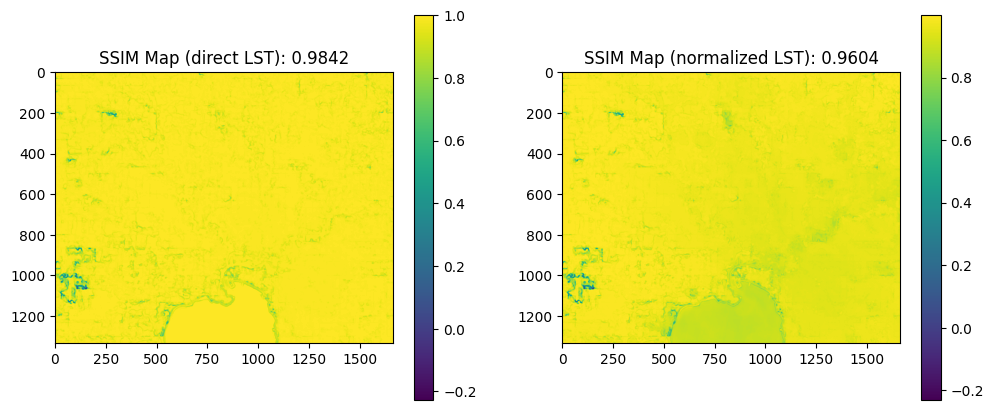

In [ ]:
# Comparison between direct LST and normalized LST for SSIM

import numpy as np
import tifffile as tiff
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import os

# --------------------------
# File paths
# --------------------------
base_path = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_BASE_fine_20230107.tif"
pred_path = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\dSTARFM_20221203.tif"

# Load rasters
base = tiff.imread(base_path).astype(np.float32)
fused = tiff.imread(pred_path).astype(np.float32)

# Mask extreme NoData
base[base < -1e30] = np.nan
fused[fused < -1e30] = np.nan

# --------------------------
# 1️⃣ SSIM on direct LST
# --------------------------
mask = np.isfinite(base) & np.isfinite(fused)
base_masked = np.where(mask, base, 0)
fused_masked = np.where(mask, fused, 0)

data_range = np.nanmax(base_masked) - np.nanmin(base_masked)
ssim_direct, ssim_map_direct = ssim(base_masked, fused_masked, data_range=data_range, full=True)

print("SSIM on direct LST:", ssim_direct)

# --------------------------
# 2️⃣ SSIM on normalized LST (0–1)
# --------------------------
def normalize(img):
    return (img - np.nanmin(img)) / (np.nanmax(img) - np.nanmin(img))

base_norm = normalize(base_masked)
fused_norm = normalize(fused_masked)

ssim_norm, ssim_map_norm = ssim(base_norm, fused_norm, data_range=1.0, full=True)
print("SSIM on normalized LST:", ssim_norm)

# --------------------------
# Plot side-by-side SSIM maps
# --------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(ssim_map_direct, cmap="viridis")
plt.colorbar()
plt.title(f"SSIM Map (direct LST): {ssim_direct:.4f}")

plt.subplot(1,2,2)
plt.imshow(ssim_map_norm, cmap="viridis")
plt.colorbar()
plt.title(f"SSIM Map (normalized LST): {ssim_norm:.4f}")

plt.show()


dSTARFM_20221203.tif SSIM (vs base): 0.9842


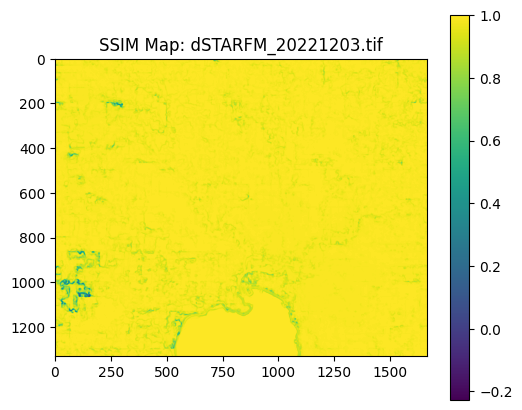

dSTARFM_20221227.tif SSIM (vs base): 0.9842


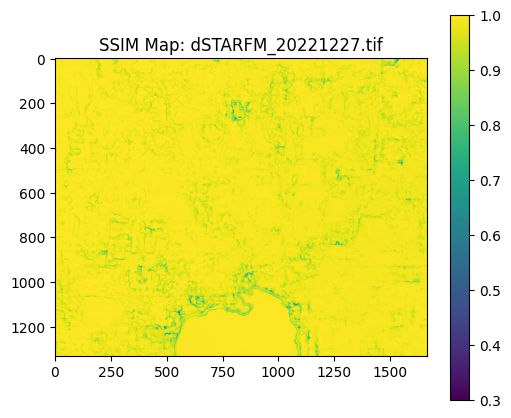

dSTARFM_20230127.tif SSIM (vs base): 0.9847


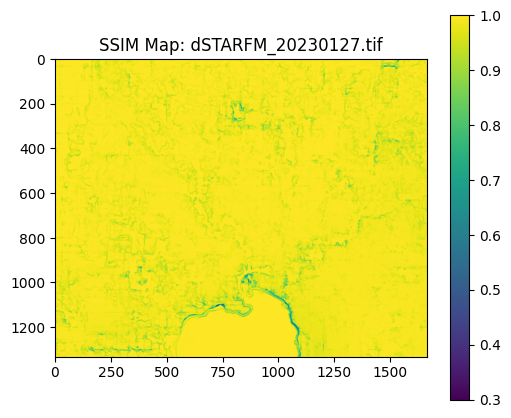

In [28]:
import numpy as np
import tifffile as tiff
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import os

# --------------------------
# Base image (used for all predictions)
# --------------------------
base_path = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_BASE_fine_20230107.tif"
base = tiff.imread(base_path).astype(np.float32)
base[base < -1e30] = np.nan  # mask extreme NoData

# --------------------------
# List all prediction dates
# --------------------------
prediction_files = [
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\dSTARFM_20221203.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\dSTARFM_20221227.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\dSTARFM_20230127.tif",
    # add more prediction dates here
]

# --------------------------
# Output folder for SSIM maps
# --------------------------
output_dir = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\SSIM_maps"
os.makedirs(output_dir, exist_ok=True)

# --------------------------
# Loop over predictions
# --------------------------
for pred_path in prediction_files:
    fused = tiff.imread(pred_path).astype(np.float32)
    fused[fused < -1e30] = np.nan  # mask NoData

    # Mask valid pixels
    mask = np.isfinite(base) & np.isfinite(fused)
    base_masked = np.where(mask, base, 0)
    fused_masked = np.where(mask, fused, 0)

    # Compute data range
    data_range = np.nanmax(base_masked) - np.nanmin(base_masked)
    if data_range == 0:
        print(f"{os.path.basename(pred_path)}: data range zero, skipping SSIM")
        continue

    # Compute SSIM
    ssim_value, ssim_map = ssim(base_masked, fused_masked, data_range=data_range, full=True)
    print(f"{os.path.basename(pred_path)} SSIM (vs base): {ssim_value:.4f}")

    # Save SSIM map
    ssim_map_path = os.path.join(output_dir, f"SSIM_{os.path.basename(pred_path)}")
    tiff.imwrite(ssim_map_path, (ssim_map * 255).astype(np.uint8))  # scaled for visualization

    # Optional: plot
    plt.figure(figsize=(6,5))
    plt.imshow(ssim_map, cmap="viridis")
    plt.colorbar()
    plt.title(f"SSIM Map: {os.path.basename(pred_path)}")
    plt.show()


## 4.3  Directional ring profiling using the urban-rural LST gradients
Direction-Enhanced Adaptive Synchronous Extraction (DEASE) from (Yang et al., 2026)

- Construction and division of buffers (1 km) for 21 cardinal directions
- Extraction of LST
- Comparison of LST profile by date (weather/atmospheric variability) and by direction (spatial anisotropy/urban morphology)

### 4.3.1 Zonal Statistics
Zonal statistics were applied to:
- **STARFM** outputs for **daytime LST prediction**
- **FSDAF** outputs for **night-time LST prediction**

For each prediction date, the **mean Land Surface Temperature (LST)** was extracted:
- by **date**, and  
- by **direction** (12 radial directions),

using zones defined from the **centre point of the image**.

<img src="jpg/accuracy_DEASE_bearing_centre_point.jpg" width="1200"/>

### 4.3.2 Data analysis

In [3]:
import pandas as pd
import glob
import os

# Folder containing your CSV files
dease_csv_folder = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\DEASE_csv"

# Get all CSV files
csv_files = glob.glob(os.path.join(dease_csv_folder, "*.csv"))

# Read and concatenate
dease_all_df = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)

# Rename columns
dease_all_df = dease_all_df.rename(columns={
    "ID": "id",
    "MEAN": "mean_lst"
})

# Keep only relevant columns
dease_all_df = dease_all_df[["temporal", "date", "id", "mean_lst"]]

# Load the Constructed DEASE CSV metadata
buffer_df = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\constructed_buffers_metadata.csv")

# Make sure 'id' is string for merging
dease_all_df["id"] = dease_all_df["id"].astype(str)
buffer_df["id"] = buffer_df["id"].astype(str)

# Join with the metadata
dease_all_df_metadata = dease_all_df.merge(buffer_df, on="id", how="left")   

## Ensure the "Centre of urban areas" has rows for each bearing
# Filter DEASE for centre of urban areas --> distance == 0
dease_centre = dease_all_df_metadata[dease_all_df_metadata["distance"] == 0]

# DEASE centre, Bearing 255, 285, 315, 345, (15 is already in the dataset), ...
dease_centre_45 = dease_centre.copy()
dease_centre_45["direction"] = 45

dease_centre_75 = dease_centre.copy()
dease_centre_75["direction"] = 75

dease_centre_105 = dease_centre.copy()
dease_centre_105["direction"] = 105

dease_centre_135 = dease_centre.copy()
dease_centre_135["direction"] = 135

dease_centre_165 = dease_centre.copy()
dease_centre_165["direction"] = 165

dease_centre_195 = dease_centre.copy()
dease_centre_195["direction"] = 195

dease_centre_225 = dease_centre.copy()
dease_centre_225["direction"] = 225

dease_centre_255 = dease_centre.copy()
dease_centre_255["direction"] = 255

dease_centre_285 = dease_centre.copy()
dease_centre_285["direction"] = 285

dease_centre_315 = dease_centre.copy()
dease_centre_315["direction"] = 315

dease_centre_345 = dease_centre.copy()
dease_centre_345["direction"] = 345

# Concatenate all centre rows
dease_centre_all = pd.concat([
    dease_centre_45,
    dease_centre_75,
    dease_centre_105,
    dease_centre_135,
    dease_centre_165,
    dease_centre_195,
    dease_centre_225,
    dease_centre_255,
    dease_centre_285,
    dease_centre_315,
    dease_centre_345,    
], ignore_index=True)

# Combine with the original DEASE dataset
dease_all_df_metadata = pd.concat([dease_all_df_metadata, dease_centre_all], ignore_index=True)

# Create column named "use" 
dease_all_df_metadata["use"] = "prediction"  # Default to "prediction"

# Select data for daytime and nighttime separately
dease_all_df_metadata_day = dease_all_df_metadata[dease_all_df_metadata["temporal"] == "day"].copy()
dease_all_df_metadata_night = dease_all_df_metadata[dease_all_df_metadata["temporal"] == "night"].copy()

# For daytime, change the "use" to base if the date is 7/01/2023
dease_all_df_metadata_day.loc[dease_all_df_metadata_day["date"] == "7/01/2023", "use"] = "base"
# For nighttime, change the "use" to base if the date is 25/12/2022
dease_all_df_metadata_night.loc[dease_all_df_metadata_night["date"] == "25/12/2022", "use"] = "base"

# Combine back the daytime and nighttime datasets
dease_all_df_metadata_final = pd.concat([dease_all_df_metadata_day, dease_all_df_metadata_night], ignore_index=True)

# Save merged CSV
out_csv = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\dease_all_dates.csv"
dease_all_df_metadata_final.to_csv(out_csv, index=False)

dease_all_df_metadata_final.head()

,temporal,date,id,mean_lst,distance,direction,area,use
0,day,3/12/2022,361,37.179070,0,15,0.900000,prediction
1,day,3/12/2022,1,39.077419,1,165,26.158868,prediction
2,day,3/12/2022,2,38.719252,2,165,78.532089,prediction
3,day,3/12/2022,3,38.779878,3,165,130.916650,prediction
4,day,3/12/2022,4,38.709621,4,165,183.310422,prediction


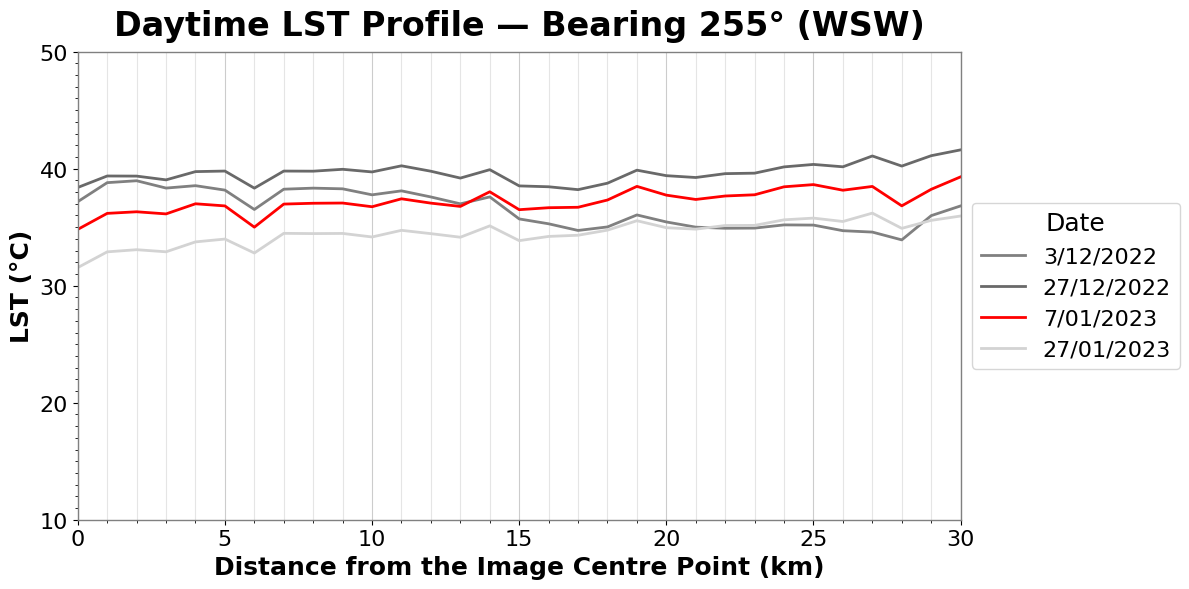

In [4]:
# Plot - One sample row from the DEASE dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Copy the dease csv file to a shorter name
dease_df = dease_all_df_metadata.copy()

# Filter for direction and temporal
dease_df_day_255 = dease_df[(dease_df["direction"] == 255) & (dease_df["temporal"] == "day")]

# Cubic smoothing spline per date
dease_df_day_255_raw = (
    dease_df_day_255[["date", "distance", "mean_lst"]]
    .sort_values(["date", "distance"])
    .reset_index(drop=True)
)

# Order dates (oldest --> newest)
date_order = [
    "3/12/2022",
    "27/12/2022",
    "7/01/2023",
    "27/01/2023"
]

dease_df_day_255_raw["date"] = pd.Categorical(
    dease_df_day_255_raw["date"],
    categories=date_order,
    ordered=True
)

# Define colours
date_colors = {
    "3/12/2022":  "gray",
    "27/12/2022": "dimgray",
    "7/01/2023":  "red",
    "27/01/2023": "lightgray"
}

# Plot smoothed curves
fig, ax = plt.subplots(figsize=(12, 6))

for date, g in dease_df_day_255_raw.groupby("date"):
    ax.plot(
        g["distance"],
        g["mean_lst"],
        label=date,
        color=date_colors.get(date, "gray"),
        linewidth=2
    )

# Axis labels and title
ax.set_xlim(0, 30)
ax.set_ylim(10, 50)

ax.set_xticks(np.arange(0, 31, 5))
ax.set_xticks(np.arange(0, 31, 1), minor=True)

ax.set_yticks(np.arange(10, 51, 10))
ax.set_yticks(np.arange(10, 51, 1), minor=True)


# labels and title
ax.set_title("Daytime LST Profile — Bearing 255° (WSW)", fontsize=24, fontweight="bold", pad=12)

ax.set_xlabel("Distance from the Image Centre Point (km)", fontsize=18, fontweight="bold")
ax.set_ylabel("LST (°C)", fontsize=18, fontweight="bold")

# Grid, legend, Styling 
ax.grid(which="major", axis="x", color="grey", alpha=0.4)
ax.grid(which="minor", axis="x", color="grey", alpha=0.2)

ax.tick_params(axis="both", labelsize=16)

legend = ax.legend(
    title="Date",
    fontsize=16,
    title_fontsize=18,
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

for spine in ax.spines.values():
    spine.set_color("grey")
    spine.set_linewidth(1)

plt.tight_layout()
plt.show()


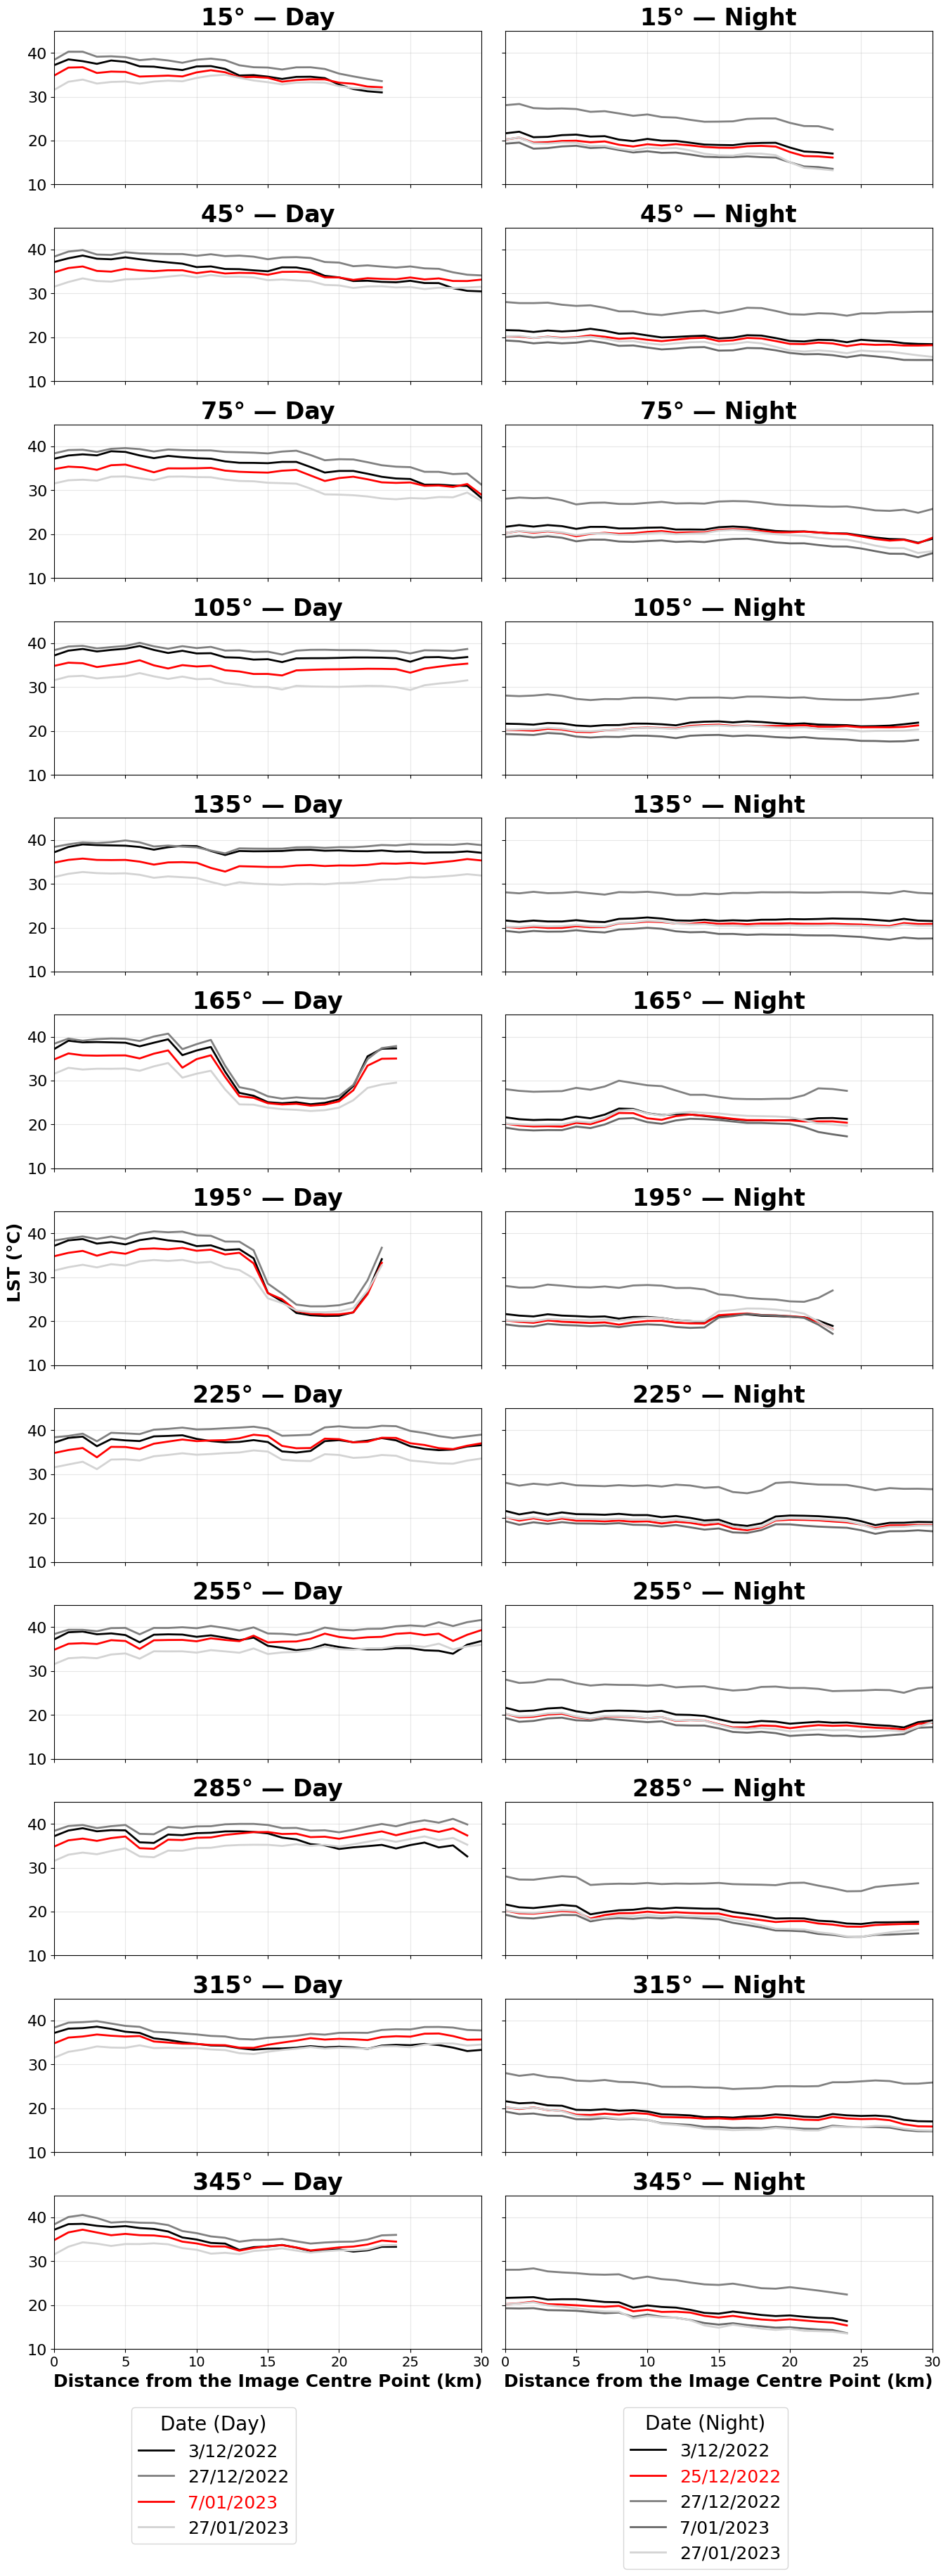

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# Filter
dease_df_day = dease_df[dease_df["temporal"] == "day"]
dease_df_night = dease_df[dease_df["temporal"] == "night"]

# Define colours
date_colors_day = {
    "3/12/2022":  "black",
    "27/12/2022": "gray",
    "7/01/2023":  "red",
    "27/01/2023": "lightgray"
}

date_order_day = ["3/12/2022", "27/12/2022", "7/01/2023", "27/01/2023"]


# Define colours
date_colors_night = {
    "3/12/2022":  "black",
    "25/12/2022": "red",
    "27/12/2022": "gray",
    "7/01/2023":  "dimgray",
    "27/01/2023": "lightgray"
}

date_order_night = ["3/12/2022", "25/12/2022", "27/12/2022", "7/01/2023", "27/01/2023"]

bearings = sorted(dease_df["direction"].unique())

fig, axes = plt.subplots(
    nrows=len(bearings),
    ncols=2,
    figsize=(14, 3 * len(bearings)),
    sharex=True,
    sharey=True
)

# If only one bearing
if len(bearings) == 1:
    axes = np.array([axes])

for i, bearing in enumerate(bearings):

    ax_day = axes[i, 0]
    ax_night = axes[i, 1]

    # -------- DAY --------
    df_day = (
        dease_df_day[dease_df_day["direction"] == bearing]
        [["date", "distance", "mean_lst"]]
        .sort_values(["date", "distance"])
    )

    df_day["date"] = pd.Categorical(
        df_day["date"],
        categories=date_order_day,
        ordered=True
    )

    for date, g in df_day.groupby("date"):
        ax_day.plot(
            g["distance"],
            g["mean_lst"],
            label=date,
            color=date_colors_day.get(date, "gray"),
            linewidth=2
        )

    ax_day.set_title(f"{bearing}° — Day", fontsize=24, fontweight="bold")
    ax_day.grid(alpha=0.3)

    # -------- NIGHT --------
    df_night = (
        dease_df_night[dease_df_night["direction"] == bearing]
        [["date", "distance", "mean_lst"]]
        .sort_values(["date", "distance"])
    )

    df_night["date"] = pd.Categorical(
        df_night["date"],
        categories=date_order_night,
        ordered=True
    )

    for date, g in df_night.groupby("date"):
        ax_night.plot(
            g["distance"],
            g["mean_lst"],
            label=date,
            color=date_colors_night.get(date, "gray"),
            linewidth=2
        )

    ax_night.set_title(f"{bearing}° — Night", fontsize=24, fontweight="bold")
    ax_night.grid(alpha=0.3)

# Axis limits
for ax_row in axes:
    for ax in ax_row:
        ax.set_xlim(0, 30)
        ax.set_ylim(10, 45)
        ax.set_yticks(np.arange(10, 46, 10))

# Increase tick label sizes
for ax_row in axes:
    for ax in ax_row:
        ax.tick_params(axis="y", labelsize=16)
        ax.tick_params(axis="x", labelsize=14)

# Shared labels
axes[-1, 0].set_xlabel("Distance from the Image Centre Point (km)", fontsize=18, fontweight="bold")
axes[-1, 1].set_xlabel("Distance from the Image Centre Point (km)", fontsize=18, fontweight="bold")

fig.text(0.04, 0.5, "LST (°C)", va='center', rotation='vertical',
         fontsize=18, fontweight="bold")

# --- Day legend (vertical) ---
handles_day, labels_day = axes[0, 0].get_legend_handles_labels()

legend_day = fig.legend(
    handles_day,
    labels_day,
    title="Date (Day)",
    loc="lower center",
    ncol=1,             # vertical stack
    fontsize=18,
    title_fontsize=20,
    bbox_to_anchor=(0.25, -0.01)  # center under the left column
)

# Color one label red
for text in legend_day.get_texts():
    if text.get_text() == "7/01/2023":
        text.set_color("red")

# --- Night legend (vertical) ---
handles_night, labels_night = axes[0, 1].get_legend_handles_labels()

legend_night = fig.legend(
    handles_night,
    labels_night,
    title="Date (Night)",
    loc="lower center",
    ncol=1,
    fontsize=18,
    title_fontsize=20,
    bbox_to_anchor=(0.75, -0.02)
)

# Color one label red
for text in legend_night.get_texts():
    if text.get_text() == "25/12/2022":
        text.set_color("red")

plt.tight_layout(rect=[0.05, 0.05, 1, 1])
plt.show()

# Save the figure
fig.savefig(
    "day_night_LST_profiles.png",  # file name
    dpi=300,                       # resolution
    bbox_inches='tight'             # ensures legends and labels are included
)

In R, run the code [DEASE day](preprocessing/dease_example_day.txt). 
In R, run the code [DEASE night](preprocessing/dease_example_night.txt). 

Previous versions were
[DEASE day spline and GAM](preprocessing/dease_example_day_spline_gam.txt) and [DEASE night spline and GAM](preprocessing/dease_example_night_spline_gam.txt)


**Gradient-Based Analysis of Radial LST Profiles**

The spatial derivative of Land Surface Temperature (LST) was computed to assess the consistency of spatial temperature gradients:
$$
\frac{\Delta T}{\Delta d}
$$
where the distance increment $\Delta d = 1$ km.

These spatial derivatives were compared between:
- **Predicted LST profiles**, and
- **Base LST profiles**

In [5]:
# Create temp_id from temporal
dease_all_df_metadata_final["temp_id"] = dease_all_df_metadata_final["temporal"].map({
    "day": 1,
    "night": 2
})

# Create date_id (oldest --> newest)
dease_all_df_metadata_final["date"] = pd.to_datetime(dease_all_df_metadata_final["date"], dayfirst=True)
dease_all_df_metadata_final["date_id"] = dease_all_df_metadata_final["date"].rank(method="dense").astype(int)

# Concatenate into gradient_id
dease_all_df_metadata_final["gradient_id"] = (
    dease_all_df_metadata_final["temp_id"].astype(str) + "_" +
    dease_all_df_metadata_final["date_id"].astype(str) + "_" +
    dease_all_df_metadata_final["direction"].astype(str) 
)

# Buffer id (no date_id because we want to compare buffers across dates for the same direction and temporal category)
dease_all_df_metadata_final["buffer_id"] = (
    dease_all_df_metadata_final["temp_id"].astype(str) + "_" +
    dease_all_df_metadata_final["direction"].astype(str) + "_" +
    dease_all_df_metadata_final["distance"].astype(str)
)

# Sort by 1. temp-id, 2. date-id, 3. direction, 4. distance
dease_all_df_metadata_final = dease_all_df_metadata_final.sort_values(["temp_id", "date_id", "direction", "distance"]).reset_index(drop=True)

# Display the first 30 rows of the DEASE delta dataset
dease_all_df_metadata_final.head(30)


,temporal,date,id,mean_lst,distance,direction,area,use,temp_id,date_id,gradient_id,buffer_id
0,day,2022-12-03,361,37.179070,0,15,0.900000,prediction,1,1,1_1_15,1_15_0
1,day,2022-12-03,40,38.494224,1,15,26.149934,prediction,1,1,1_1_15,1_15_1
2,day,2022-12-03,46,38.085532,2,15,78.506351,prediction,1,1,1_1_15,1_15_2
3,day,2022-12-03,59,37.480061,3,15,130.871230,prediction,1,1,1_1_15,1_15_3
4,day,2022-12-03,69,38.238366,4,15,183.246919,prediction,1,1,1_1_15,1_15_4
5,day,2022-12-03,81,37.946716,5,15,235.597027,prediction,1,1,1_1_15,1_15_5
6,day,2022-12-03,92,36.910628,6,15,287.960623,prediction,1,1,1_1_15,1_15_6
7,day,2022-12-03,103,36.835274,7,15,340.284752,prediction,1,1,1_1_15,1_15_7
8,day,2022-12-03,114,36.410098,8,15,392.695837,prediction,1,1,1_1_15,1_15_8
9,day,2022-12-03,125,36.063703,9,15,445.061890,prediction,1,1,1_1_15,1_15_9


In [6]:
# Retrieve delta T
dease_all_df_metadata_final["delta_T"] = (
    dease_all_df_metadata_final
    .groupby(["temp_id", "date_id", "direction"])["mean_lst"]
    .diff()
)

# Display the first 30 rows of the DEASE delta dataset
dease_all_df_metadata_final.head(30)

,temporal,date,id,mean_lst,distance,direction,area,use,temp_id,date_id,gradient_id,buffer_id,delta_T
0,day,2022-12-03,361,37.179070,0,15,0.900000,prediction,1,1,1_1_15,1_15_0,NaN
1,day,2022-12-03,40,38.494224,1,15,26.149934,prediction,1,1,1_1_15,1_15_1,1.315154
2,day,2022-12-03,46,38.085532,2,15,78.506351,prediction,1,1,1_1_15,1_15_2,-0.408692
3,day,2022-12-03,59,37.480061,3,15,130.871230,prediction,1,1,1_1_15,1_15_3,-0.605471
4,day,2022-12-03,69,38.238366,4,15,183.246919,prediction,1,1,1_1_15,1_15_4,0.758306
5,day,2022-12-03,81,37.946716,5,15,235.597027,prediction,1,1,1_1_15,1_15_5,-0.291650
6,day,2022-12-03,92,36.910628,6,15,287.960623,prediction,1,1,1_1_15,1_15_6,-1.036089
7,day,2022-12-03,103,36.835274,7,15,340.284752,prediction,1,1,1_1_15,1_15_7,-0.075353
8,day,2022-12-03,114,36.410098,8,15,392.695837,prediction,1,1,1_1_15,1_15_8,-0.425177
9,day,2022-12-03,125,36.063703,9,15,445.061890,prediction,1,1,1_1_15,1_15_9,-0.346395


In [7]:
# Remove delta_T with NaN 
dease_delta = (
    dease_all_df_metadata_final
    .dropna(subset=["delta_T"])
    .sort_values(["temp_id", "date_id", "direction", "distance"])
    .reset_index(drop=True)
)

# Create dease_delta_base (filter use == "base")
dease_delta_base = dease_delta[dease_delta["use"] == "base"].copy()

# Rename delta_T --> delta_T_base
dease_delta_base = dease_delta_base.rename(columns={"delta_T": "delta_T_base", "mean_lst": "mean_lst_base"})

# Join back to the main delta dataset
dease_delta = dease_delta.merge(dease_delta_base[["buffer_id", "delta_T_base", "mean_lst_base"]], on="buffer_id", how="left")

# Filter an example of buffer_id with both base and prediction rows (example: buffer_id == "1_255_1" --> day, bearing 255, distance 1km from the centre point)
dease_delta_example = dease_delta[dease_delta["buffer_id"] == "1_255_1"]

# Display an example of buffer_id with both base and prediction rows 
dease_delta_example.head()

,temporal,date,id,mean_lst,distance,direction,area,use,temp_id,date_id,gradient_id,buffer_id,delta_T,delta_T_base,mean_lst_base
219,day,2022-12-03,36,38.805411,1,255,26.149313,prediction,1,1,1_1_255,1_255_1,1.626341,1.367811,36.181066
551,day,2022-12-27,36,39.375154,1,255,26.149313,prediction,1,3,1_3_255,1_255_1,0.980933,1.367811,36.181066
883,day,2023-01-07,36,36.181066,1,255,26.149313,base,1,4,1_4_255,1_255_1,1.367811,1.367811,36.181066
1215,day,2023-01-27,36,32.891874,1,255,26.149313,prediction,1,5,1_5_255,1_255_1,1.344148,1.367811,36.181066


In [8]:
# Remove all rows where use == "base"
dease_delta_filtered = dease_delta[
    dease_delta["use"] != "base"
].copy()

# Filter for daytime only
dease_delta_day = dease_delta_filtered[dease_delta_filtered["temporal"] == "day"].copy()

# Filter for nighttime only
dease_delta_night = dease_delta_filtered[dease_delta_filtered["temporal"] == "night"].copy()

# Display the first 30 rows of the DEASE delta dataset
dease_delta.head(30)

# Save dease delta CSV
out_csv_delta = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\dease_delta.csv"
dease_delta.to_csv(out_csv_delta, index=False)

In [8]:
# Paired t-test for daytime
from scipy import stats

t_stat, p_value = stats.ttest_rel(
    dease_delta_day["delta_T"],
    dease_delta_day["delta_T_base"],
    nan_policy="omit"  # ignores NaNs
)

print("t-statistic:", t_stat)
print("p-value:", p_value)


t-statistic: -4.207373685789249
p-value: 2.8168669281776683e-05


### 4.3.3 Compute MAE, RMSE, Pearson correlation by date and direction
- Global
- By date → weather / atmospheric variability
- By direction → spatial anisotropy / urban morphology

#### a. Daytime

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# ---------------------------
# Example: dease_delta_day already filtered for temporal == "day"
# Columns: distance, delta_T, delta_T_base
# ---------------------------

# Compute error metrics (absolute difference)
mae = (dease_delta_day["delta_T"] - dease_delta_day["delta_T_base"]).abs().mean()
rmse = np.sqrt(((dease_delta_day["delta_T"] - dease_delta_day["delta_T_base"])**2).mean())
corr, _ = pearsonr(dease_delta_day["delta_T"], dease_delta_day["delta_T_base"])

print(f"MAE: {mae:.3f} °C")
print(f"RMSE: {rmse:.3f} °C")
print(f"Pearson correlation: {corr:.3f}")


MAE: 0.223 °C
RMSE: 0.313 °C
Pearson correlation: 0.958


In [10]:
from IPython.display import display

# check the number of rows per date in dease_delta_day
dease_delta_day.groupby("date").size()
display(dease_delta_day.groupby("date").size())

# Metrics by date, direction, and both date and direction
def compute_metrics(dease_delta_day):
    diff = dease_delta_day["delta_T"] - dease_delta_day["delta_T_base"]
    
    mae = diff.abs().mean()
    rmse = np.sqrt((diff**2).mean())
    
    # Guard against constant values
    if dease_delta_day["delta_T"].nunique() > 1 and dease_delta_day["delta_T_base"].nunique() > 1:
        corr, _ = pearsonr(dease_delta_day["delta_T"], dease_delta_day["delta_T_base"])
    else:
        corr = np.nan
        
    return pd.Series({
        "MAE": mae,
        "RMSE": rmse,
        "Pearson_r": corr
    })

day_metrics_by_date = (
    dease_delta_day
    .groupby("date")
    .apply(compute_metrics)
    .reset_index()
)

day_metrics_by_date
day_metrics_by_direction = (
    dease_delta_day
    .groupby("direction")
    .apply(compute_metrics)
    .reset_index()
)

day_metrics_by_date_direction = (
    dease_delta_day
    .groupby(["date", "direction"])
    .apply(compute_metrics)
    .reset_index()
)


display(day_metrics_by_date)
display(day_metrics_by_direction)
display(day_metrics_by_date_direction)

out_csv_metrics_date_direction = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\day_metrics_by_date_direction.csv"
day_metrics_by_date_direction.to_csv(out_csv_metrics_date_direction, index=False)

date
2022-12-03    332
2022-12-27    332
2023-01-27    332
dtype: int64

,date,MAE,RMSE,Pearson_r
0,2022-12-03,0.240357,0.312182,0.967826
1,2022-12-27,0.207945,0.271704,0.969392
2,2023-01-27,0.221971,0.349762,0.962265


,direction,MAE,RMSE,Pearson_r
0,15,0.264661,0.331742,0.878837
1,45,0.195739,0.246655,0.874542
2,75,0.224897,0.284336,0.918822
3,105,0.172112,0.217720,0.927374
4,135,0.134621,0.177907,0.916715
5,165,0.335599,0.532121,0.969174
6,195,0.332301,0.491477,0.979484
7,225,0.247991,0.299761,0.958959
8,255,0.258475,0.335873,0.931258
9,285,0.204288,0.270846,0.956206


,date,direction,MAE,RMSE,Pearson_r
0,2022-12-03,15,0.307907,0.380184,0.867068
1,2022-12-03,45,0.235376,0.279979,0.899140
2,2022-12-03,75,0.208906,0.266833,0.939635
3,2022-12-03,105,0.180634,0.244040,0.907455
4,2022-12-03,135,0.140393,0.184138,0.916200
5,2022-12-03,165,0.271635,0.396707,0.990395
6,2022-12-03,195,0.285695,0.383538,0.993091
7,2022-12-03,225,0.300235,0.338296,0.942063
8,2022-12-03,255,0.313139,0.389734,0.916639
9,2022-12-03,285,0.262123,0.326767,0.974883


In [11]:
# Save metrics by date to CSV
day_table_date = (
    day_metrics_by_date
    .assign(
        MAE=lambda d: d["MAE"].round(3),
        RMSE=lambda d: d["RMSE"].round(3),
        Pearson_r=lambda d: d["Pearson_r"].round(3)
    )
    .rename(columns={
        "date": "Date",
        "Pearson_r": "r"
    })
    [["Date", "MAE", "RMSE", "r"]]
)

day_table_date

# Save metrics by direction to CSV
day_table_direction = (
    day_metrics_by_direction
    .assign(
        MAE=lambda d: d["MAE"].round(3),
        RMSE=lambda d: d["RMSE"].round(3),
        Pearson_r=lambda d: d["Pearson_r"].round(3)
    )
    .rename(columns={
        "direction": "Direction",
        "Pearson_r": "r"
    })
    [["Direction", "MAE", "RMSE", "r"]]
)

day_table_direction

out_csv_metrics_date = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\day_metrics_by_date.csv"
day_table_date.to_csv(out_csv_metrics_date, index=False)

out_csv_metrics_direction = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\day_metrics_by_direction.csv"
day_table_direction.to_csv(out_csv_metrics_direction, index=False)



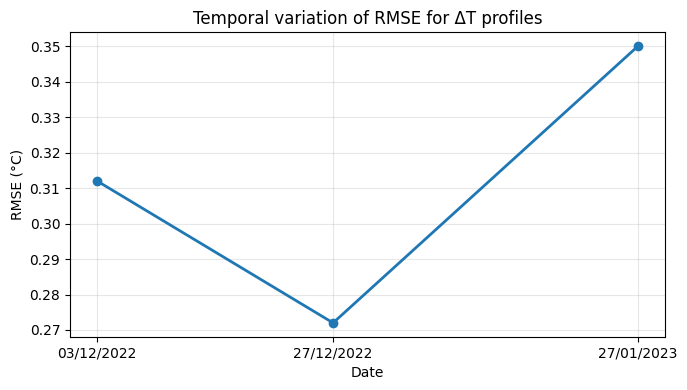

In [12]:
# Plot RMSE vs date
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import pandas as pd


# Ensure Date column is datetime
day_table_date['Date'] = pd.to_datetime(day_table_date['Date'])

plt.figure(figsize=(7, 4))

plt.plot(
    day_table_date["Date"],
    day_table_date["RMSE"],
    marker="o",
    linewidth=2
)

plt.xlabel("Date")
plt.ylabel("RMSE (°C)")
plt.title("Temporal variation of RMSE for ΔT profiles")

# Use only your dates as ticks
plt.xticks(day_table_date['Date'], day_table_date['Date'].dt.strftime('%d/%m/%Y'), rotation=0)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


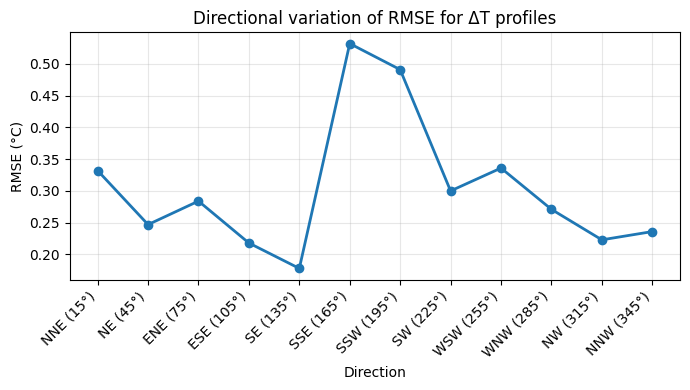

In [13]:
# Plot RMSE vs direction
import matplotlib.pyplot as plt

direction_labels = {
    15:  "NNE (15°)",
    45:  "NE (45°)",
    75:  "ENE (75°)",
    105: "ESE (105°)",
    135: "SE (135°)",
    165: "SSE (165°)",
    195: "SSW (195°)",
    225: "SW (225°)",
    255: "WSW (255°)",
    285: "WNW (285°)",
    315: "NW (315°)",
    345: "NNW (345°)"
}

# Sort directions for clean plotting
plot_df = day_table_direction.sort_values("Direction")

plt.figure(figsize=(7, 4))

plt.plot(
    plot_df["Direction"],
    plot_df["RMSE"],
    marker="o",
    linewidth=2
)

# Custom ticks
plt.xticks(
    ticks=plot_df["Direction"],
    labels=[direction_labels[d] for d in plot_df["Direction"]],
    rotation=45,
    ha="right"
)

plt.xlabel("Direction")
plt.ylabel("RMSE (°C)")
plt.title("Directional variation of RMSE for ΔT profiles")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


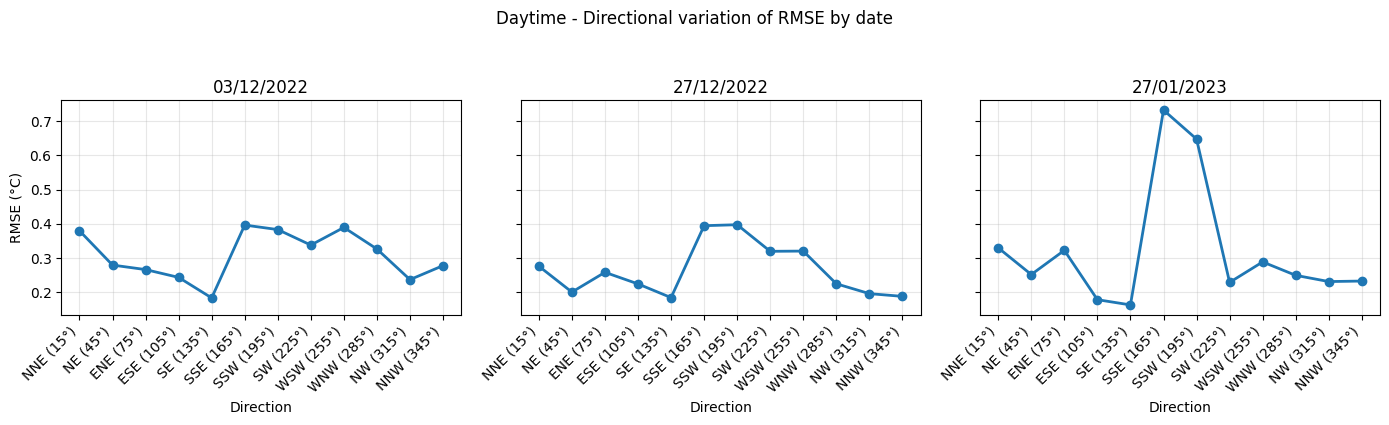

In [14]:
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import pandas as pd
# Plot by date and direction
# Recompute the metrics by date and direction
day_metrics_by_date_direction = (
    dease_delta_day
    .groupby(["date", "direction"])
    .apply(compute_metrics)
    .reset_index()
)


# Direction labels for plotting
direction_labels = {
    15:  "NNE (15°)",
    45:  "NE (45°)",
    75:  "ENE (75°)",
    105: "ESE (105°)",
    135: "SE (135°)",
    165: "SSE (165°)",
    195: "SSW (195°)",
    225: "SW (225°)",
    255: "WSW (255°)",
    285: "WNW (285°)",
    315: "NW (315°)",
    345: "NNW (345°)"
}


# Plot RMSE by date and direction
dates = sorted(day_metrics_by_date_direction["date"].unique())

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(dates),
    figsize=(14, 4),
    sharey=True
)

for ax, date in zip(axes, dates):
    df_plot = (
        day_metrics_by_date_direction
        [day_metrics_by_date_direction["date"] == date]
        .sort_values("direction")
    )
    
    ax.plot(
        df_plot["direction"],
        df_plot["RMSE"],
        marker="o",
        linewidth=2
    )
    
    # Format date as DD/MM/YYYY
    ax.set_title(pd.Timestamp(date).strftime('%d/%m/%Y'))
    
    ax.set_xlabel("Direction")
    ax.set_xticks(df_plot["direction"])
    ax.set_xticklabels(
        [direction_labels[d] for d in df_plot["direction"]],
        rotation=45,
        ha="right"
    )
    
    ax.grid(True, alpha=0.3)


axes[0].set_ylabel("RMSE (°C)")

plt.suptitle("Daytime - Directional variation of RMSE by date", y=1.05)
plt.tight_layout()

# Save the plot locally (PNG, PDF, etc.)
plt.savefig("day_RMSE_vs_date_and_direction.png", dpi=300)

plt.show()


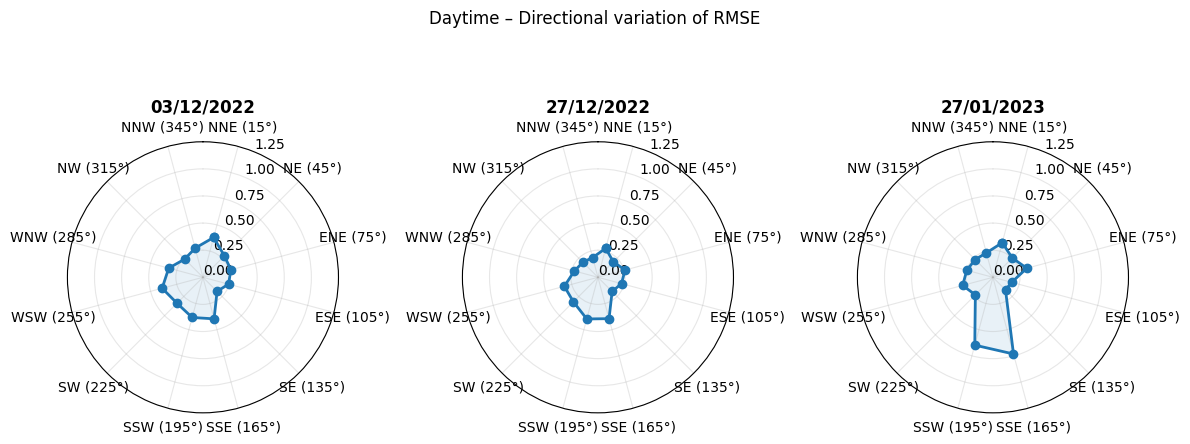

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Get sorted unique dates
dates = sorted(day_metrics_by_date_direction["date"].unique())

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(dates),
    subplot_kw={'projection': 'polar'},
    figsize=(4 * len(dates), 4)
)

# If only one date, axes is not iterable
if len(dates) == 1:
    axes = [axes]

for ax, date in zip(axes, dates):
    
    df_plot = (
        day_metrics_by_date_direction
        [day_metrics_by_date_direction["date"] == date]
        .sort_values("direction")
    )
    
    theta = np.deg2rad(df_plot["direction"].values)
    values = df_plot["RMSE"].values
    
    # Close circle
    theta = np.append(theta, theta[0])
    values = np.append(values, values[0])
    
    ax.plot(theta, values, marker="o", linewidth=2)
    ax.fill(theta, values, alpha=0.1)
    
    # ✅ Geographic orientation
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    
    # ✅ Fixed radial limits
    ax.set_ylim(0, 1.25)
    ax.set_yticks(np.arange(0, 1.26, 0.25))
    
    ax.set_title(pd.Timestamp(date).strftime('%d/%m/%Y'), fontweight='bold')

    angles = df_plot["direction"].values
    ax.set_xticks(np.deg2rad(angles))
    ax.set_xticklabels([direction_labels[d] for d in angles])

    # Set direction labels
    ax.set_xticks(np.deg2rad(df_plot["direction"]))
    ax.set_xticklabels(
        [direction_labels[d] for d in df_plot["direction"]]
    )
    
    ax.grid(True, alpha=0.3)


plt.suptitle("Daytime – Directional variation of RMSE", y=1.1)
plt.tight_layout()

plt.savefig("day_RMSE_polar.png", dpi=300)
plt.show()


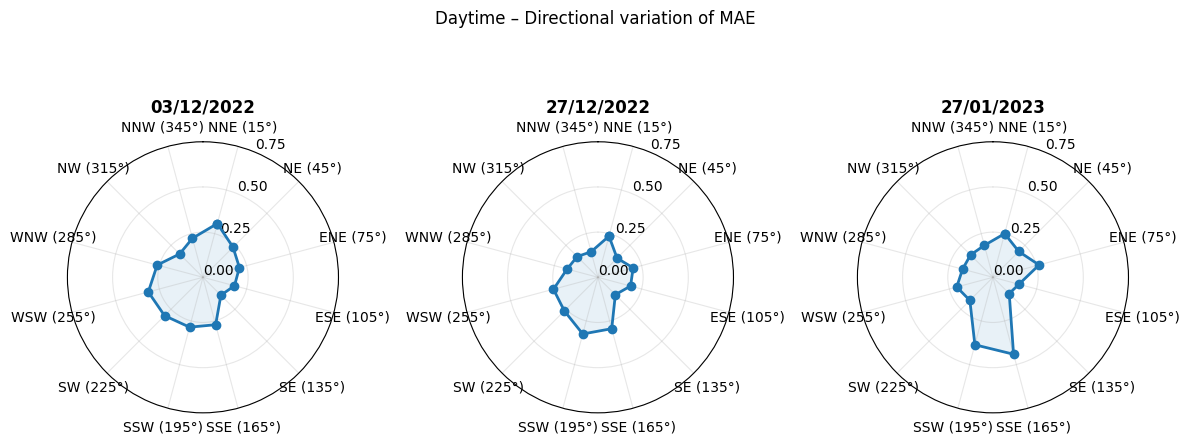

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Get sorted unique dates
dates = sorted(day_metrics_by_date_direction["date"].unique())

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(dates),
    subplot_kw={'projection': 'polar'},
    figsize=(4 * len(dates), 4)
)

# If only one date, axes is not iterable
if len(dates) == 1:
    axes = [axes]

for ax, date in zip(axes, dates):
    
    df_plot = (
        day_metrics_by_date_direction
        [day_metrics_by_date_direction["date"] == date]
        .sort_values("direction")
    )
    
    theta = np.deg2rad(df_plot["direction"].values)
    values = df_plot["MAE"].values
    
    # Close circle
    theta = np.append(theta, theta[0])
    values = np.append(values, values[0])
    
    ax.plot(theta, values, marker="o", linewidth=2)
    ax.fill(theta, values, alpha=0.1)
    
    # ✅ Geographic orientation
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    
    # ✅ Fixed radial limits
    ax.set_ylim(0, 0.75)
    ax.set_yticks(np.arange(0, 0.76, 0.25))
    
    ax.set_title(pd.Timestamp(date).strftime('%d/%m/%Y'), fontweight='bold')

    angles = df_plot["direction"].values
    ax.set_xticks(np.deg2rad(angles))
    ax.set_xticklabels([direction_labels[d] for d in angles])

    # Set direction labels
    ax.set_xticks(np.deg2rad(df_plot["direction"]))
    ax.set_xticklabels(
        [direction_labels[d] for d in df_plot["direction"]]
    )
    
    ax.grid(True, alpha=0.3)

plt.suptitle("Daytime – Directional variation of MAE", y=1.1)
plt.tight_layout()

plt.savefig("day_MAE_polar.png", dpi=300)
plt.show()


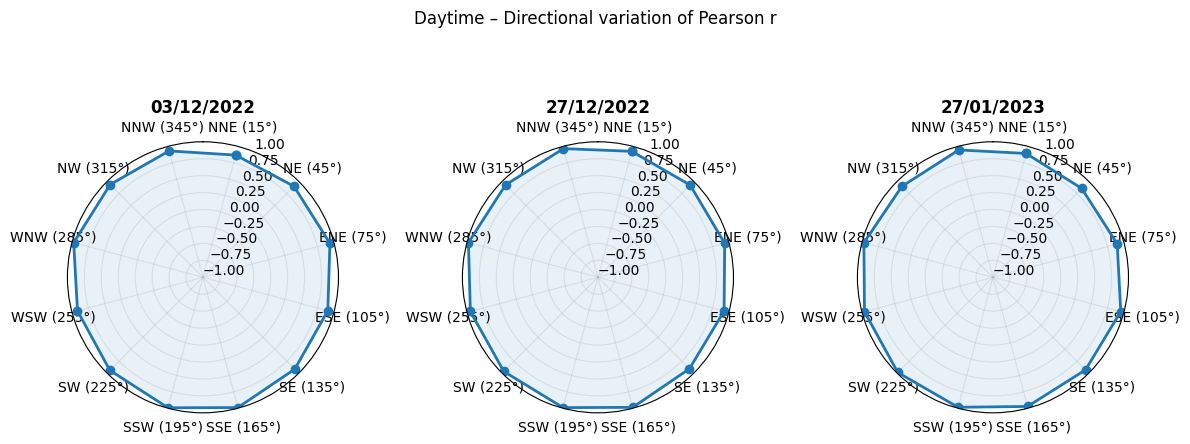

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Get sorted unique dates
dates = sorted(day_metrics_by_date_direction["date"].unique())

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(dates),
    subplot_kw={'projection': 'polar'},
    figsize=(4 * len(dates), 4)
)

# If only one date, axes is not iterable
if len(dates) == 1:
    axes = [axes]

for ax, date in zip(axes, dates):
    
    df_plot = (
        day_metrics_by_date_direction
        [day_metrics_by_date_direction["date"] == date]
        .sort_values("direction")
    )
    
    theta = np.deg2rad(df_plot["direction"].values)
    values = df_plot["Pearson_r"].values
    
    # Close circle
    theta = np.append(theta, theta[0])
    values = np.append(values, values[0])
    
    ax.plot(theta, values, marker="o", linewidth=2)
    ax.fill(theta, values, alpha=0.1)
    
    # ✅ Geographic orientation
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    
    # ✅ Fixed radial limits
    ax.set_ylim(-1, 1)
    ax.set_yticks(np.arange(-1, 1.01, 0.25))
    
    ax.set_title(pd.Timestamp(date).strftime('%d/%m/%Y'), fontweight='bold')

    angles = df_plot["direction"].values
    ax.set_xticks(np.deg2rad(angles))
    ax.set_xticklabels([direction_labels[d] for d in angles])

    # Set direction labels
    ax.set_xticks(np.deg2rad(df_plot["direction"]))
    ax.set_xticklabels(
        [direction_labels[d] for d in df_plot["direction"]]
    )
    
    ax.grid(True, alpha=0.3)

plt.suptitle("Daytime – Directional variation of Pearson r", y=1.1)
plt.tight_layout()

plt.savefig("day_Pearson_r_polar.png", dpi=300)
plt.show()

#### b. Nighttime

In [45]:
# Compute error metrics (absolute difference)
mae = (dease_delta_night["delta_T"] - dease_delta_night["delta_T_base"]).abs().mean()
rmse = np.sqrt(((dease_delta_night["delta_T"] - dease_delta_night["delta_T_base"])**2).mean())
corr, _ = pearsonr(dease_delta_night["delta_T"], dease_delta_night["delta_T_base"])

print(f"MAE: {mae:.3f} °C")
print(f"RMSE: {rmse:.3f} °C")
print(f"Pearson correlation: {corr:.3f}")


MAE: 0.134 °C
RMSE: 0.230 °C
Pearson correlation: 0.865


In [26]:
from IPython.display import display

# check the number of rows per date in dease_delta_night
dease_delta_night.groupby("date").size()
display(dease_delta_night.groupby("date").size())

# Metrics by date, direction, and both date and direction
def compute_metrics(dease_delta_night):
    diff = dease_delta_night["delta_T"] - dease_delta_night["delta_T_base"]
    
    mae = diff.abs().mean()
    rmse = np.sqrt((diff**2).mean())
    
    # Guard against constant values
    if dease_delta_night["delta_T"].nunique() > 1 and dease_delta_night["delta_T_base"].nunique() > 1:
        corr, _ = pearsonr(dease_delta_night["delta_T"], dease_delta_night["delta_T_base"])
    else:
        corr = np.nan
        
    return pd.Series({
        "MAE": mae,
        "RMSE": rmse,
        "Pearson_r": corr
    })

night_metrics_by_date = (
    dease_delta_night
    .groupby("date")
    .apply(compute_metrics)
    .reset_index()
)

night_metrics_by_date
night_metrics_by_direction = (
    dease_delta_night
    .groupby("direction")
    .apply(compute_metrics)
    .reset_index()
)

night_metrics_by_date_direction = (
    dease_delta_night
    .groupby(["date", "direction"])
    .apply(compute_metrics)
    .reset_index()
)


display(night_metrics_by_date)
display(night_metrics_by_direction)
display(night_metrics_by_date_direction)

out_csv_metrics_date_direction = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\night_metrics_by_date_direction.csv"
night_metrics_by_date_direction.to_csv(out_csv_metrics_date_direction, index=False)

date
2022-12-03    332
2022-12-27    332
2023-01-07    332
2023-01-27    332
dtype: int64

,date,MAE,RMSE,Pearson_r
0,2022-12-03,0.088322,0.123174,0.962220
1,2022-12-27,0.198824,0.371239,0.635496
2,2023-01-07,0.120096,0.163297,0.936830
3,2023-01-27,0.127463,0.177715,0.931890


,direction,MAE,RMSE,Pearson_r
0,15,0.149238,0.180528,0.938868
1,45,0.122990,0.155761,0.919186
2,75,0.125946,0.166777,0.939469
3,105,0.103153,0.132848,0.867376
4,135,0.083649,0.106735,0.929408
5,165,0.211258,0.381911,0.767078
6,195,0.233795,0.553555,0.628429
7,225,0.088777,0.116787,0.975384
8,255,0.127395,0.182029,0.922746
9,285,0.131775,0.177375,0.930441


,date,direction,MAE,RMSE,Pearson_r
0,2022-12-03,15,0.085974,0.111931,0.972489
1,2022-12-03,45,0.089716,0.112338,0.955670
2,2022-12-03,75,0.105031,0.132737,0.968845
3,2022-12-03,105,0.084724,0.113732,0.897733
4,2022-12-03,135,0.071973,0.086939,0.951197
5,2022-12-03,165,0.131356,0.197265,0.939328
6,2022-12-03,195,0.116933,0.185620,0.979635
7,2022-12-03,225,0.053657,0.073732,0.991319
8,2022-12-03,255,0.059102,0.079425,0.987593
9,2022-12-03,285,0.082258,0.106509,0.978208


In [47]:
# Save metrics by date to CSV
night_table_date = (
    night_metrics_by_date
    .assign(
        MAE=lambda d: d["MAE"].round(3),
        RMSE=lambda d: d["RMSE"].round(3),
        Pearson_r=lambda d: d["Pearson_r"].round(3)
    )
    .rename(columns={
        "date": "Date",
        "Pearson_r": "r"
    })
    [["Date", "MAE", "RMSE", "r"]]
)

night_table_date

# Save metrics by direction to CSV
night_table_direction = (
    night_metrics_by_direction
    .assign(
        MAE=lambda d: d["MAE"].round(3),
        RMSE=lambda d: d["RMSE"].round(3),
        Pearson_r=lambda d: d["Pearson_r"].round(3)
    )
    .rename(columns={
        "direction": "Direction",
        "Pearson_r": "r"
    })
    [["Direction", "MAE", "RMSE", "r"]]
)

night_table_direction

out_csv_metrics_date = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\night_metrics_by_date.csv"
night_table_date.to_csv(out_csv_metrics_date, index=False)

out_csv_metrics_direction = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\night_metrics_by_direction.csv"
night_table_direction.to_csv(out_csv_metrics_direction, index=False)


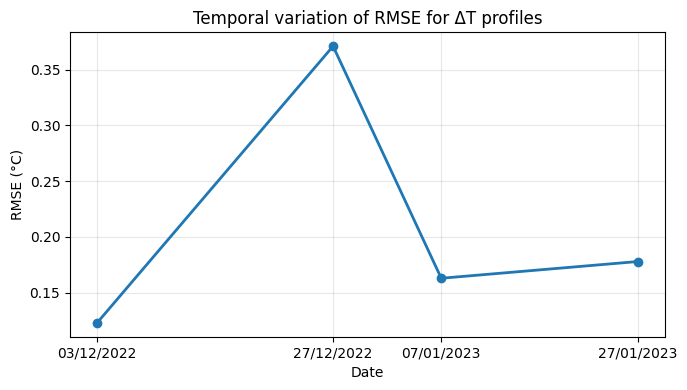

In [49]:
# Plot RMSE vs date
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import pandas as pd


# Ensure Date column is datetime
night_table_date['Date'] = pd.to_datetime(night_table_date['Date'])

plt.figure(figsize=(7, 4))

plt.plot(
    night_table_date["Date"],
    night_table_date["RMSE"],
    marker="o",
    linewidth=2
)

plt.xlabel("Date")
plt.ylabel("RMSE (°C)")
plt.title("Temporal variation of RMSE for ΔT profiles")

# Use only your dates as ticks
plt.xticks(night_table_date['Date'], night_table_date['Date'].dt.strftime('%d/%m/%Y'), rotation=0)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

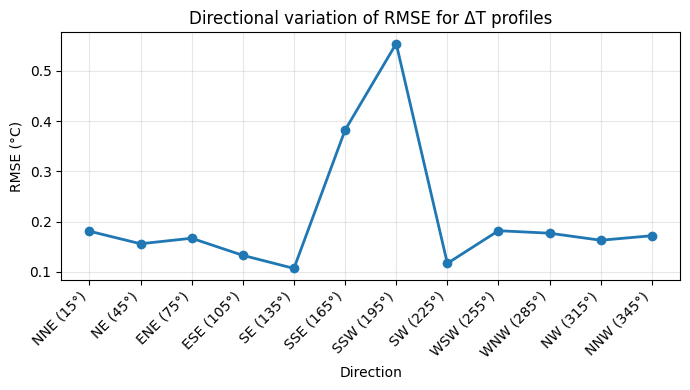

In [ ]:
# Plot RMSE vs direction
import matplotlib.pyplot as plt

direction_labels = {
    15:  "NNE (15°)",
    45:  "NE (45°)",
    75:  "ENE (75°)",
    105: "ESE (105°)",
    135: "SE (135°)",
    165: "SSE (165°)",
    195: "SSW (195°)",
    225: "SW (225°)",
    255: "WSW (255°)",
    285: "WNW (285°)",
    315: "NW (315°)",
    345: "NNW (345°)"
}

# Sort directions for clean plotting
plot_df = night_table_direction.sort_values("Direction")

plt.figure(figsize=(7, 4))

plt.plot(
    plot_df["Direction"],
    plot_df["RMSE"],
    marker="o",
    linewidth=2
)

# Custom ticks
plt.xticks(
    ticks=plot_df["Direction"],
    labels=[direction_labels[d] for d in plot_df["Direction"]],
    rotation=45,
    ha="right"
)

plt.xlabel("Direction")
plt.ylabel("RMSE (°C)")
plt.title("Directional variation of RMSE for ΔT profiles")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


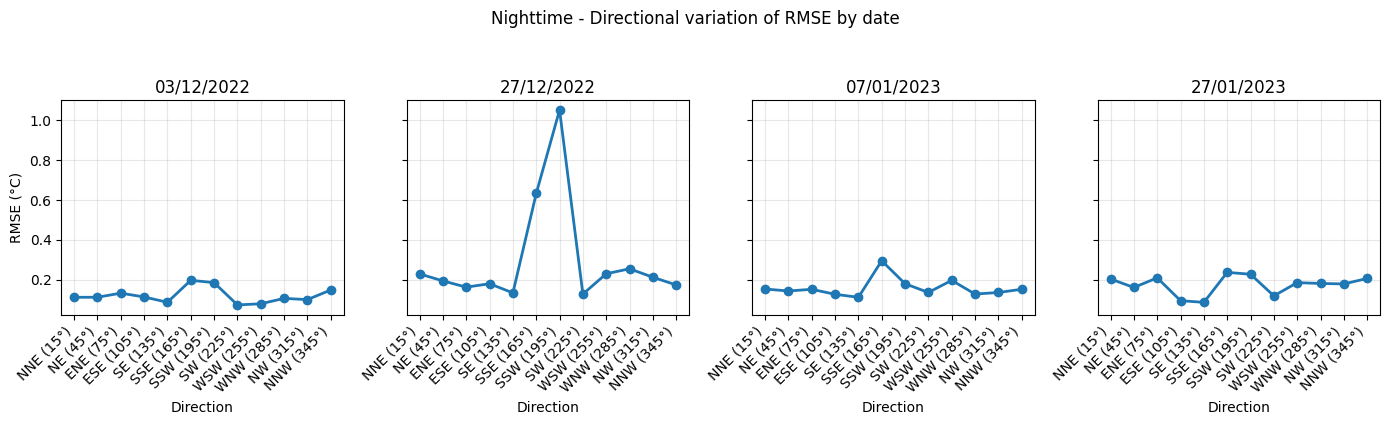

In [56]:
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import pandas as pd
# Plot by date and direction
# Recompute the metrics by date and direction
night_metrics_by_date_direction = (
    dease_delta_night
    .groupby(["date", "direction"])
    .apply(compute_metrics)
    .reset_index()
)


# Direction labels for plotting
direction_labels = {
    15:  "NNE (15°)",
    45:  "NE (45°)",
    75:  "ENE (75°)",
    105: "ESE (105°)",
    135: "SE (135°)",
    165: "SSE (165°)",
    195: "SSW (195°)",
    225: "SW (225°)",
    255: "WSW (255°)",
    285: "WNW (285°)",
    315: "NW (315°)",
    345: "NNW (345°)"
}


# Plot RMSE by date and direction
dates = sorted(night_metrics_by_date_direction["date"].unique())

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(dates),
    figsize=(14, 4),
    sharey=True
)

for ax, date in zip(axes, dates):
    df_plot = (
        night_metrics_by_date_direction
        [night_metrics_by_date_direction["date"] == date]
        .sort_values("direction")
    )
    
    ax.plot(
        df_plot["direction"],
        df_plot["RMSE"],
        marker="o",
        linewidth=2
    )
    
    # Format date as DD/MM/YYYY
    ax.set_title(pd.Timestamp(date).strftime('%d/%m/%Y'))
    
    ax.set_xlabel("Direction")
    ax.set_xticks(df_plot["direction"])
    ax.set_xticklabels(
        [direction_labels[d] for d in df_plot["direction"]],
        rotation=45,
        ha="right"
    )
    
    ax.grid(True, alpha=0.3)


axes[0].set_ylabel("RMSE (°C)")

plt.suptitle("Nighttime - Directional variation of RMSE by date", y=1.05)
plt.tight_layout()

# Save the plot locally (PNG, PDF, etc.)
plt.savefig("night_RMSE_vs_date_and_direction.png", dpi=300)

plt.show()

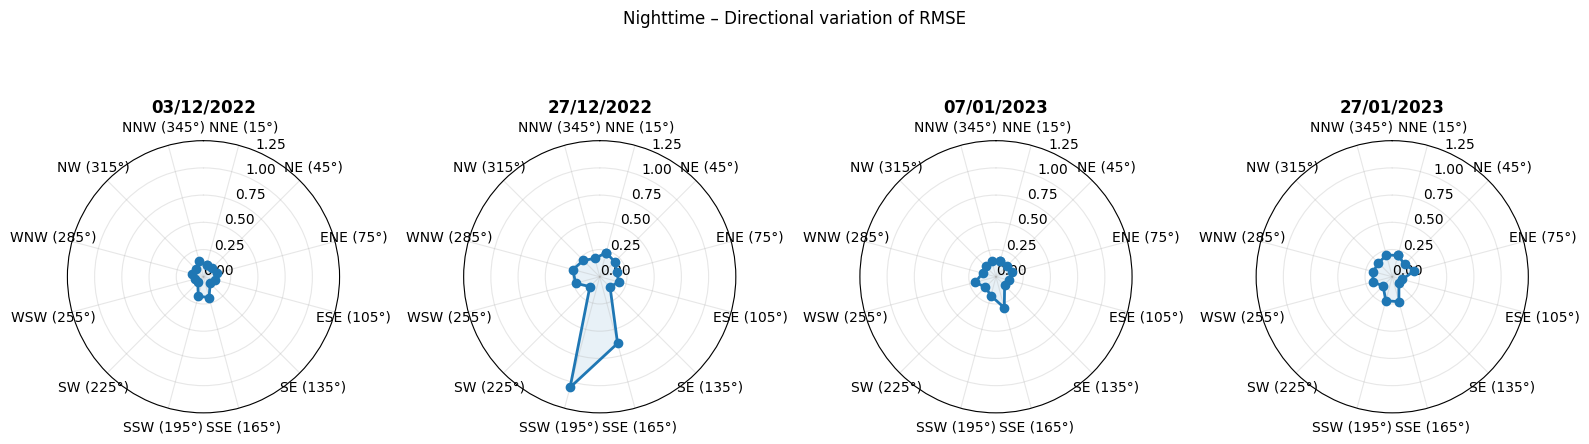

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Get sorted unique dates
dates = sorted(night_metrics_by_date_direction["date"].unique())

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(dates),
    subplot_kw={'projection': 'polar'},
    figsize=(4 * len(dates), 4)
)

# If only one date, axes is not iterable
if len(dates) == 1:
    axes = [axes]

for ax, date in zip(axes, dates):
    
    df_plot = (
        night_metrics_by_date_direction
        [night_metrics_by_date_direction["date"] == date]
        .sort_values("direction")
    )
    
    theta = np.deg2rad(df_plot["direction"].values)
    values = df_plot["RMSE"].values
    
    # Close circle
    theta = np.append(theta, theta[0])
    values = np.append(values, values[0])
    
    ax.plot(theta, values, marker="o", linewidth=2)
    ax.fill(theta, values, alpha=0.1)
    
    # ✅ Geographic orientation
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    
    # ✅ Fixed radial limits
    ax.set_ylim(0, 1.25)
    ax.set_yticks(np.arange(0, 1.26, 0.25))
    
    ax.set_title(pd.Timestamp(date).strftime('%d/%m/%Y'), fontweight='bold')
    
    ax.set_xticks(np.deg2rad(df_plot["direction"]))
    ax.set_xticklabels(
        [direction_labels[d] for d in df_plot["direction"]]
    )
    
    ax.grid(True, alpha=0.3)

plt.suptitle("Nighttime – Directional variation of RMSE", y=1.1)
plt.tight_layout()

plt.savefig("night_RMSE_polar.png", dpi=300)
plt.show()


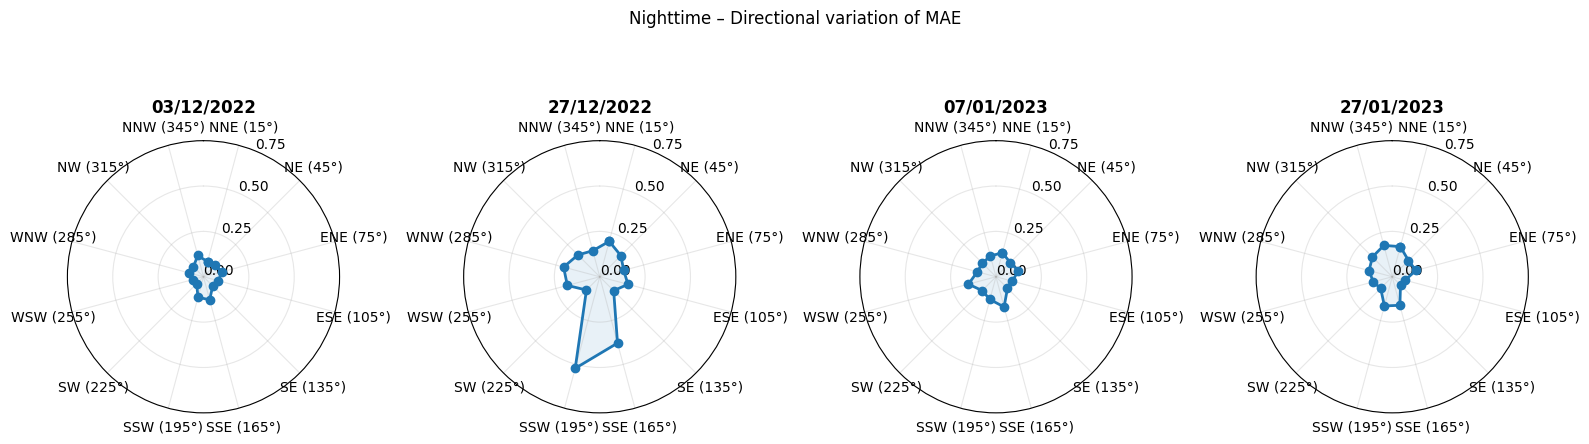

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Get sorted unique dates
dates = sorted(night_metrics_by_date_direction["date"].unique())

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(dates),
    subplot_kw={'projection': 'polar'},
    figsize=(4 * len(dates), 4)
)

# If only one date, axes is not iterable
if len(dates) == 1:
    axes = [axes]

for ax, date in zip(axes, dates):
    
    df_plot = (
        night_metrics_by_date_direction
        [night_metrics_by_date_direction["date"] == date]
        .sort_values("direction")
    )
    
    theta = np.deg2rad(df_plot["direction"].values)
    values = df_plot["MAE"].values
    
    # Close circle
    theta = np.append(theta, theta[0])
    values = np.append(values, values[0])
    
    ax.plot(theta, values, marker="o", linewidth=2)
    ax.fill(theta, values, alpha=0.1)
    
    # ✅ Geographic orientation
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    
    # ✅ Fixed radial limits
    ax.set_ylim(0, 0.75)
    ax.set_yticks(np.arange(0, 0.76, 0.25))
    
    ax.set_title(pd.Timestamp(date).strftime('%d/%m/%Y'), fontweight='bold')
    
    ax.set_xticks(np.deg2rad(df_plot["direction"]))
    ax.set_xticklabels(
        [direction_labels[d] for d in df_plot["direction"]]
    )
    
    ax.grid(True, alpha=0.3)

plt.suptitle("Nighttime – Directional variation of MAE", y=1.1)
plt.tight_layout()

plt.savefig("night_MAE_polar.png", dpi=300)
plt.show()

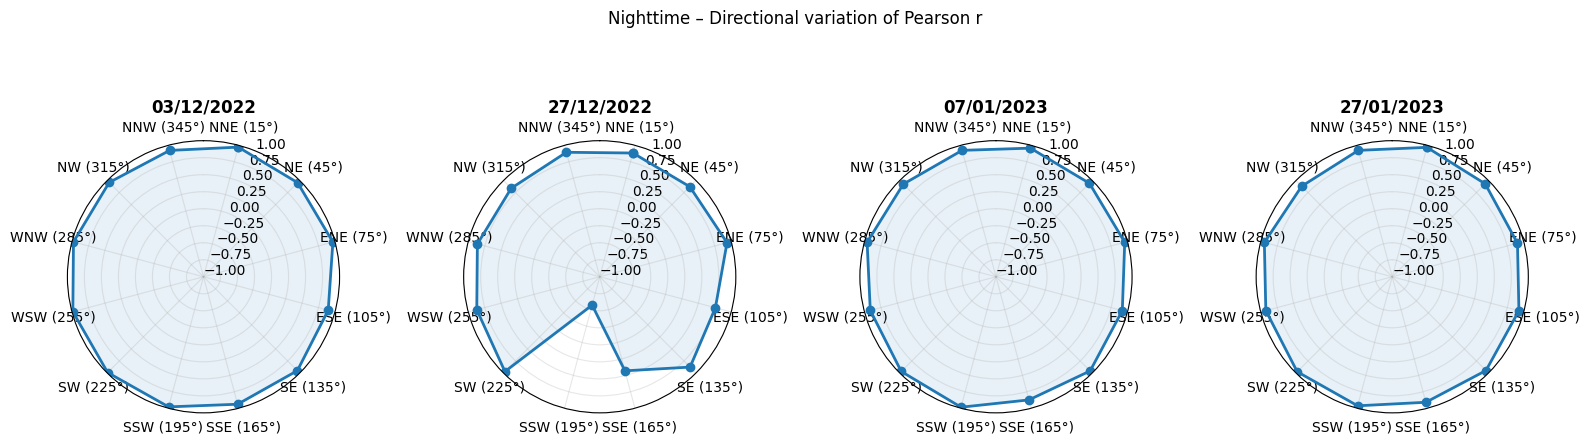

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Get sorted unique dates
dates = sorted(night_metrics_by_date_direction["date"].unique())

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(dates),
    subplot_kw={'projection': 'polar'},
    figsize=(4 * len(dates), 4)
)

# If only one date, axes is not iterable
if len(dates) == 1:
    axes = [axes]

for ax, date in zip(axes, dates):
    
    df_plot = (
        night_metrics_by_date_direction
        [night_metrics_by_date_direction["date"] == date]
        .sort_values("direction")
    )
    
    theta = np.deg2rad(df_plot["direction"].values)
    values = df_plot["Pearson_r"].values
    
    # Close circle
    theta = np.append(theta, theta[0])
    values = np.append(values, values[0])
    
    ax.plot(theta, values, marker="o", linewidth=2)
    ax.fill(theta, values, alpha=0.1)
    
    # ✅ Geographic orientation
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    
    # ✅ Fixed radial limits
    ax.set_ylim(-1, 1)
    ax.set_yticks(np.arange(-1, 1.01, 0.25))
    
    ax.set_title(pd.Timestamp(date).strftime('%d/%m/%Y'), fontweight='bold')
    
    ax.set_xticks(np.deg2rad(df_plot["direction"]))
    ax.set_xticklabels(
        [direction_labels[d] for d in df_plot["direction"]]
    )
    
    ax.grid(True, alpha=0.3)

plt.suptitle("Nighttime – Directional variation of Pearson r", y=1.1)
plt.tight_layout()

plt.savefig("night_Pearson_r_polar.png", dpi=300)
plt.show()

### 4.3.4 Summary of RMSE between Prediction and Base iamge of spatial derivative LST

<table align="center">
  <tr>
    <td><img src="day_RMSE_vs_date_and_direction.png" width="1200"/></td>
  </tr>
  <tr>
    <td><img src="night_RMSE_vs_date_and_direction.png" width="1200"/></td>
  </tr>
</table>

# 4. Normalized LST
Remove the water area, keep only land pixel

In [12]:
import tifffile as tiff
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# File paths
path1 = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\nLST\day_base.tif"
path2 = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\nLST\day_20221203.tif"

# Read raster arrays
lst1 = tiff.imread(path1)
lst2 = tiff.imread(path2)

print("Shapes:", lst1.shape, lst2.shape)
assert lst1.shape == lst2.shape, "Rasters must have same shape"

# Flatten and mask
lst1_flat = lst1.flatten()
lst2_flat = lst2.flatten()
mask = np.isfinite(lst1_flat) & np.isfinite(lst2_flat)  # handles NaNs and infs

x = lst1_flat[mask]
y = lst2_flat[mask]

print("Valid pixels:", x.shape, y.shape)

# RMSE
rmse = np.sqrt(mean_squared_error(x, y))

# R²
r2 = r2_score(x, y)

print("x shape:", x.shape, "y shape:", y.shape)
print("x unique:", np.unique(x))
print("y unique:", np.unique(y))



Shapes: (1332, 1665) (1332, 1665)
Valid pixels: (2217780,) (2217780,)
x shape: (2217780,) y shape: (2217780,)
x unique: [-3.40282347e+38  1.07304345e-07  1.31506305e-02 ...  9.94455695e-01
  9.98607755e-01  1.00000012e+00]


c:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\.venv\lib\site-packages\numpy\core\_methods.py:179: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


y unique: [-3.40282347e+38  1.21671349e-07  1.25870835e-02 ...  9.93506014e-01
  9.98188794e-01  1.00000012e+00]


Valid pixels: (2090035,) (2090035,)
RMSE: 0.08400647
R²: -0.32316819461281665
y = 0.750x + 0.182


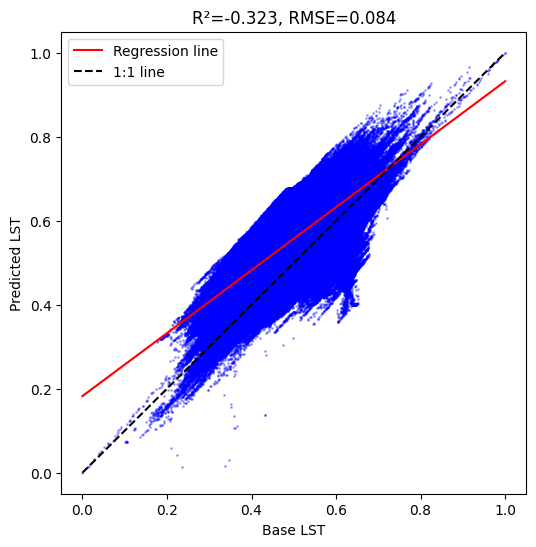

In [14]:
import tifffile as tiff
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# File paths
path1 = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\nLST\day_base.tif"
path2 = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\nLST\day_20221203.tif"

# Read rasters
lst1 = tiff.imread(path1).astype(np.float32)
lst2 = tiff.imread(path2).astype(np.float32)

# Flatten
lst1_flat = lst1.flatten()
lst2_flat = lst2.flatten()

# Define NoData/sentinel threshold
nodata_val = -3.4e38

# Mask out extreme values and NaNs
mask_valid = (
    np.isfinite(lst1_flat) & np.isfinite(lst2_flat) & 
    (lst1_flat < 1e5) & (lst1_flat > -1e5) &
    (lst2_flat < 1e5) & (lst2_flat > -1e5)
)

x = lst1_flat[mask_valid]
y = lst2_flat[mask_valid]

print("Valid pixels:", x.shape, y.shape)

# RMSE
rmse = np.sqrt(mean_squared_error(x, y))

# R²
r2 = r2_score(x, y)

# Linear regression
model = LinearRegression()
model.fit(x.reshape(-1,1), y)
slope = model.coef_[0]
intercept = model.intercept_

print("RMSE:", rmse)
print("R²:", r2)
print(f"y = {slope:.3f}x + {intercept:.3f}")

# Plot
plt.figure(figsize=(6,6))
plt.scatter(x, y, s=1, alpha=0.3, color="blue")
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, slope*x_line + intercept, color="red", label="Regression line")
plt.plot(x_line, x_line, linestyle="--", color="black", label="1:1 line")

plt.xlabel("Base LST")
plt.ylabel("Predicted LST")
plt.title(f"R²={r2:.3f}, RMSE={rmse:.3f}")
plt.legend()
plt.show()

# 4. Comparison against air temperature at BOM stations
The LST data for the target dates were compared with air temperature.


## 4.1 LST extraction
First, the fused STARFM outputs were exported to the output folder using filenames such as `d_refer_20230107`, in which the date is encoded as an 8-character string (`YYYYMMDD`) and preceded by an additional 8 characters.

Secondly, for each raster file in the output folder, the LST is extracted using the PWRS and CWS shapefile 
...\shapefile\wn_bom_pt.7z
To do the extraction, the following code was used in ARCGIS [PRWS and CWS LST](preprocessing/pwrs_cws_lst_extraction.txt)

## 4.2 Comparison between LST and Air temperature

In [62]:
# load the extracted LST data
day_lst = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\day_pwrs_cws_lst.csv")
night_lst = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\night_pwrs_cws_lst.csv")

# LST Convert the date column to datetime format
day_lst['date'] = pd.to_datetime(day_lst['date'], format='%d/%m/%Y')
night_lst['date'] = pd.to_datetime(night_lst['date'], format='%d/%m/%Y')

# Add the Time_AEDT column
day_lst['Time_AEDT'] = pd.to_datetime(day_lst['date']) + pd.Timedelta(hours=11)
night_lst['Time_AEDT'] = pd.to_datetime(night_lst['date']) + pd.Timedelta(hours=24)

# Add temporal information to day_lst and night_lst
day_lst['temporal'] = 'day'
night_lst['temporal'] = 'night'

# Keep the date format only day/month/year
day_lst['date'] = day_lst['date'].dt.strftime('%d/%m/%Y')
night_lst['date'] = night_lst['date'].dt.strftime('%d/%m/%Y')

# Add use information whether reference or target
day_lst['use'] = day_lst['date'].eq('07/01/2023').map({True: 'base', False: 'prediction'})
night_lst['use'] = night_lst['date'].eq('25/12/2022').map({True: 'base', False: 'prediction'})

# Merge day_lst with night_lst
day_night_lst = pd.concat([day_lst, night_lst], ignore_index=True)

# Preview first 40 rows
display(day_night_lst.head(5))

,p_id,source,date,lst_pred,Time_AEDT,temporal,use
0,1004,cws,03/12/2022,33.198058,2022-12-03 11:00:00,day,prediction
1,1010,cws,03/12/2022,37.639220,2022-12-03 11:00:00,day,prediction
2,1011,cws,03/12/2022,37.363447,2022-12-03 11:00:00,day,prediction
3,1016,cws,03/12/2022,37.205113,2022-12-03 11:00:00,day,prediction
4,1017,cws,03/12/2022,37.664265,2022-12-03 11:00:00,day,prediction


In [63]:
# load the air temperature data with UHI inn Chapter 1
air_temp = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\chapter1\output\pwrs_cws_raw.csv")

# Keep only relevant columns
air_temp = air_temp[['p_id', 'Time_AEDT', 'Time_UTC', 'ta']]

# Preview first 5 rows
display(air_temp.head(5))

c:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\.venv\lib\site-packages\IPython\core\interactiveshell.py:3553: DtypeWarning: Columns (2) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


,p_id,Time_AEDT,Time_UTC,ta
0,200,2022-12-01 00:00:00,2022-11-30 13:00:00,13.9
1,200,2022-12-01 01:00:00,2022-11-30 14:00:00,12.7
2,200,2022-12-01 02:00:00,2022-11-30 15:00:00,12.1
3,200,2022-12-01 03:00:00,2022-11-30 16:00:00,11.9
4,200,2022-12-01 04:00:00,2022-11-30 17:00:00,12.5


In [64]:
# Make sure both Time_AEDT columns are datetime
air_temp['Time_AEDT'] = pd.to_datetime(air_temp['Time_AEDT'])
day_night_lst['Time_AEDT'] = pd.to_datetime(day_night_lst['Time_AEDT'])

# Merge LST with air temperature data
lst_air_temp = pd.merge(day_night_lst, air_temp, on=['p_id', 'Time_AEDT'], how='inner')

# Keep the date format only day/month/year
# lst_air_temp['date'] = lst_air_temp['date'].dt.strftime('%d/%m/%Y')

# Order columns
lst_air_temp = lst_air_temp[['temporal', 'use', 'p_id', 'source', 'date', 'Time_AEDT', 'Time_UTC', 'lst_pred', 'ta']]

# Preview first 5 rows
display(lst_air_temp.head(5))

,temporal,use,p_id,source,date,Time_AEDT,Time_UTC,lst_pred,ta
0,day,prediction,1004,cws,03/12/2022,2022-12-03 11:00:00,2022-03-12 00:00:00,33.198058,25.4
1,day,prediction,1010,cws,03/12/2022,2022-12-03 11:00:00,2022-03-12 00:00:00,37.639220,26.6
2,day,prediction,1011,cws,03/12/2022,2022-12-03 11:00:00,2022-03-12 00:00:00,37.363447,25.7
3,day,prediction,1016,cws,03/12/2022,2022-12-03 11:00:00,2022-03-12 00:00:00,37.205113,22.7
4,day,prediction,1017,cws,03/12/2022,2022-12-03 11:00:00,2022-03-12 00:00:00,37.664265,25.3


In [65]:
# Filter PRWS only
lst_air_temp_prws = lst_air_temp[lst_air_temp['source'] == 'prws']

# Check the number of rows
num_rows = len(lst_air_temp_prws)
print(f"Number of rows for PRWS only: {num_rows}.")

# Preview all rows
display(lst_air_temp_prws.head(num_rows))

# Export to CSV
lst_air_temp_prws.to_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\lst_air_temp_prws.csv", index=False)

Number of rows for PRWS only: 45.


,temporal,use,p_id,source,date,Time_AEDT,Time_UTC,lst_pred,ta
241,day,prediction,400,prws,03/12/2022,2022-12-03 11:00:00,2022-12-03 00:00:00,33.751797,26.1
242,day,prediction,200,prws,03/12/2022,2022-12-03 11:00:00,2022-12-03 00:00:00,37.289041,26.7
243,day,prediction,600,prws,03/12/2022,2022-12-03 11:00:00,2022-12-03 00:00:00,37.697760,28.3
244,day,prediction,500,prws,03/12/2022,2022-12-03 11:00:00,2022-12-03 00:00:00,38.241858,27.3
245,day,prediction,300,prws,03/12/2022,2022-12-03 11:00:00,2022-12-03 00:00:00,35.678723,26.6
503,day,prediction,400,prws,27/12/2022,2022-12-27 11:00:00,2022-12-27 00:00:00,36.009568,31.6
504,day,prediction,200,prws,27/12/2022,2022-12-27 11:00:00,2022-12-27 00:00:00,39.431096,32.6
505,day,prediction,600,prws,27/12/2022,2022-12-27 11:00:00,2022-12-27 00:00:00,41.721304,33.4
506,day,prediction,500,prws,27/12/2022,2022-12-27 11:00:00,2022-12-27 00:00:00,38.050427,31.5
507,day,prediction,300,prws,27/12/2022,2022-12-27 11:00:00,2022-12-27 00:00:00,38.510894,32.6


**Plot**
To compare the LST with the Air temperature, the equivalent R code can be found [here](preprocessing/R_lst_air_temperature_plot.txt)

Paired t-test: Ttest_relResult(statistic=-16.11430228750514, pvalue=1.5505126851563265e-12)
Paired Wilcoxon test: WilcoxonResult(statistic=0.0, pvalue=1.9073486328125e-06)


c:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\.venv\lib\site-packages\ipykernel_launcher.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


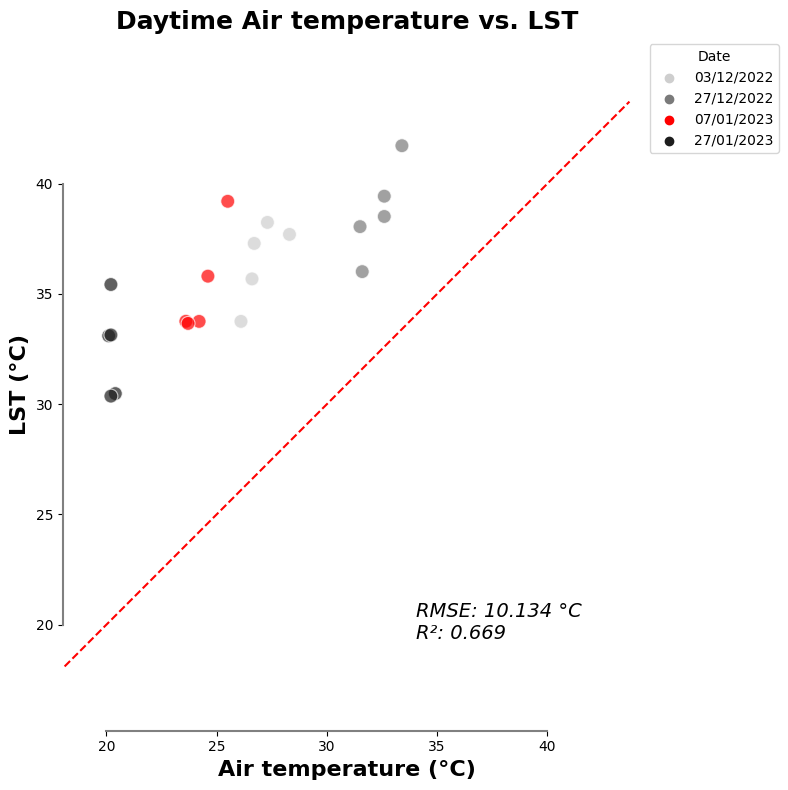

Paired t-test (night): Ttest_relResult(statistic=1.7998253164917721, pvalue=0.08447318334915456)
Paired Wilcoxon test (night): WilcoxonResult(statistic=104.0, pvalue=0.11993378400802612)
Paired t-test (night): Ttest_relResult(statistic=1.7998253164917721, pvalue=0.08447318334915456)
Paired Wilcoxon test (night): WilcoxonResult(statistic=104.0, pvalue=0.11993378400802612)


c:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\.venv\lib\site-packages\ipykernel_launcher.py:270: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


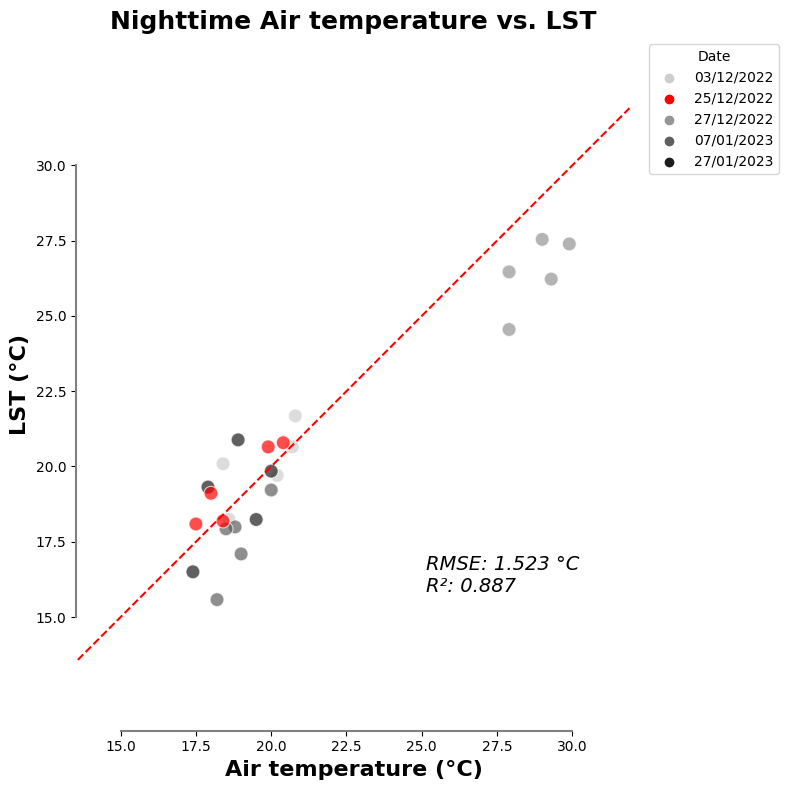

In [69]:
import pandas as pd
import numpy as np
from scipy import stats
from matplotlib.colors import to_hex
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Filter temporal == 'day'
# -------------------------
lst_air_temp_prws_day = lst_air_temp_prws[lst_air_temp_prws['temporal'] == 'day'].copy()

# -------------------------
# Paired tests
# -------------------------
t_test_result_day = stats.ttest_rel(
    lst_air_temp_prws_day['ta'],
    lst_air_temp_prws_day['lst_pred'],
    nan_policy='omit'
)
print("Paired t-test:", t_test_result_day)

wilcox_result_day = stats.wilcoxon(
    lst_air_temp_prws_day['ta'],
    lst_air_temp_prws_day['lst_pred'],
    zero_method='wilcox',
    alternative='two-sided'
)
print("Paired Wilcoxon test:", wilcox_result_day)

# -------------------------
# R² and RMSE
# -------------------------
r2 = np.corrcoef(
    lst_air_temp_prws_day['ta'],
    lst_air_temp_prws_day['lst_pred']
)[0, 1] ** 2

rmse = np.sqrt(
    np.mean((lst_air_temp_prws_day['ta'] - lst_air_temp_prws_day['lst_pred']) ** 2)
)

info_text = f"RMSE: {rmse:.3f} °C\nR²: {r2:.3f}"

# -------------------------
# Set plot limits
# -------------------------
min_val = min(
    lst_air_temp_prws_day['ta'].min(),
    lst_air_temp_prws_day['lst_pred'].min()
)
max_val = max(
    lst_air_temp_prws_day['ta'].max(),
    lst_air_temp_prws_day['lst_pred'].max()
)

# -------------------------
# Date handling
# -------------------------
lst_air_temp_prws['date'] = pd.to_datetime(
    lst_air_temp_prws['date'],
    dayfirst=True
)

lst_air_temp_prws_day['date'] = pd.to_datetime(
    lst_air_temp_prws_day['date'],
    dayfirst=True
)

# -------------------------
# Create date_str (used for hue & palette)
# -------------------------
lst_air_temp_prws_day['date_str'] = lst_air_temp_prws_day['date'].dt.strftime('%d/%m/%Y')

# -------------------------
# Target dates (string-based, ordered)
# -------------------------
target_dates_str = (
    lst_air_temp_prws_day.loc[
        lst_air_temp_prws_day['use'] == 'prediction', 'date_str'
    ]
    .drop_duplicates()
    .sort_values(
        key=lambda x: pd.to_datetime(x, dayfirst=True)
    )
)

# -------------------------
# Grey → black gradient
# -------------------------
cmap = plt.cm.Greys
gradient_colors = [
    to_hex(cmap(i))
    for i in np.linspace(0.3, 0.9, len(target_dates_str))
]

target_color_map = dict(zip(target_dates_str, gradient_colors))

# -------------------------
# Full palette
# -------------------------
palette = {}

for _, row in lst_air_temp_prws_day[['date_str', 'use']].drop_duplicates().iterrows():
    if row['use'] == 'prediction':
        palette[row['date_str']] = target_color_map[row['date_str']]
    else:
        palette[row['date_str']] = 'red'


# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(8, 8))

sns.scatterplot(
    data=lst_air_temp_prws_day,
    x='ta',
    y='lst_pred',
    hue='date_str',
    palette=palette,
    s=100,
    alpha=0.7
)

# Identity line
plt.plot(
    [min_val - 2, max_val + 2],
    [min_val - 2, max_val + 2],
    ls='--',
    color='red'
)

# Annotation
plt.text(
    x=18 + 0.6 * (max_val - 15),
    y=18 + 0.05 * (max_val - 15),
    s=info_text,
    fontsize=14,
    fontstyle='italic',
    color='black'
)

# Labels
plt.title("Daytime Air temperature vs. LST", fontsize=18, fontweight='bold')
plt.xlabel("Air temperature (°C)", fontsize=16, fontweight='bold')
plt.ylabel("LST (°C)", fontsize=16, fontweight='bold')

# Axis limits
plt.xlim(min_val -2, max_val + 2)
plt.ylim(min_val -2, max_val + 2)

# Square axes
plt.gca().set_aspect('equal', adjustable='datalim')

# Frame styling
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('grey')

ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')

sns.despine(trim=True)
plt.grid(False)

# -------------------------
# Chronological legend
# -------------------------
# Get handles and labels
handles, labels = ax.get_legend_handles_labels()

# Convert labels back to datetime
labels_dates = pd.to_datetime(labels, dayfirst=True)

# Get the order
order = np.argsort(labels_dates)

# Reorder legend
plt.legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    title='Date',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)


# -------------------------
# Save figure
# -------------------------
plt.tight_layout()
plt.savefig(
    "20260201_bom_day_observed_vs_predicted.png",
    dpi=300
)
plt.show()

#--------------------------------------------------------------------------------------------------------
# -------------------------
# Filter temporal == 'night'
# -------------------------
lst_air_temp_prws_night = lst_air_temp_prws[lst_air_temp_prws['temporal'] == 'night'].copy()

# -------------------------
# Paired tests
# -------------------------
t_test_result_night = stats.ttest_rel(
    lst_air_temp_prws_night['ta'],
    lst_air_temp_prws_night['lst_pred'],
    nan_policy='omit'
)
print("Paired t-test (night):", t_test_result_night)

wilcox_result_night = stats.wilcoxon(
    lst_air_temp_prws_night['ta'],
    lst_air_temp_prws_night['lst_pred'],
    zero_method='wilcox',
    alternative='two-sided'
)
print("Paired Wilcoxon test (night):", wilcox_result_night)

t_test_result_night = stats.ttest_rel(
    lst_air_temp_prws_night['ta'],
    lst_air_temp_prws_night['lst_pred'],
    nan_policy='omit'
)
print("Paired t-test (night):", t_test_result_night)

wilcox_result_night = stats.wilcoxon(
    lst_air_temp_prws_night['ta'],
    lst_air_temp_prws_night['lst_pred'],
    zero_method='wilcox',
    alternative='two-sided'
)
print("Paired Wilcoxon test (night):", wilcox_result_night)
# -------------------------
# R² and RMSE
# -------------------------
r2 = np.corrcoef(
    lst_air_temp_prws_night['ta'],
    lst_air_temp_prws_night['lst_pred']
)[0, 1] ** 2

rmse = np.sqrt(
    np.mean((lst_air_temp_prws_night['ta'] - lst_air_temp_prws_night['lst_pred']) ** 2)
)

info_text = f"RMSE: {rmse:.3f} °C\nR²: {r2:.3f}"

# -------------------------
# Set plot limits
# -------------------------
min_val = min(
    lst_air_temp_prws_night['ta'].min(),
    lst_air_temp_prws_night['lst_pred'].min()
)
max_val = max(
    lst_air_temp_prws_night['ta'].max(),
    lst_air_temp_prws_night['lst_pred'].max()
)

# -------------------------
# Date handling
# -------------------------
lst_air_temp_prws['date'] = pd.to_datetime(
    lst_air_temp_prws['date'],
    dayfirst=True
)

lst_air_temp_prws_night['date'] = pd.to_datetime(
    lst_air_temp_prws_night['date'],
    dayfirst=True
)

# -------------------------
# Create date_str (used for hue & palette)
# -------------------------
lst_air_temp_prws_night['date_str'] = lst_air_temp_prws_night['date'].dt.strftime('%d/%m/%Y')

# -------------------------
# Target dates (string-based, ordered)
# -------------------------
target_dates_str = (
    lst_air_temp_prws_night.loc[
        lst_air_temp_prws_night['use'] == 'prediction', 'date_str'
    ]
    .drop_duplicates()
    .sort_values(
        key=lambda x: pd.to_datetime(x, dayfirst=True)
    )
)

# -------------------------
# Grey → black gradient
# -------------------------
cmap = plt.cm.Greys
gradient_colors = [
    to_hex(cmap(i))
    for i in np.linspace(0.3, 0.9, len(target_dates_str))
]

target_color_map = dict(zip(target_dates_str, gradient_colors))

# -------------------------
# Full palette
# -------------------------
palette = {}

for _, row in lst_air_temp_prws_night[['date_str', 'use']].drop_duplicates().iterrows():
    if row['use'] == 'prediction':
        palette[row['date_str']] = target_color_map[row['date_str']]
    else:
        palette[row['date_str']] = 'red'


# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(8, 8))

sns.scatterplot(
    data=lst_air_temp_prws_night,
    x='ta',
    y='lst_pred',
    hue='date_str',
    palette=palette,
    s=100,
    alpha=0.7
)

# Identity line
plt.plot(
    [min_val -2, max_val + 2],
    [min_val -2, max_val + 2],
    ls='--',
    color='red'
)

# Annotation
plt.text(
    x=15 + 0.6 * (max_val - 13),
    y=15 + 0.05 * (max_val - 13),
    s=info_text,
    fontsize=14,
    fontstyle='italic',
    color='black'
)

# Labels
plt.title("Nighttime Air temperature vs. LST", fontsize=18, fontweight='bold')
plt.xlabel("Air temperature (°C)", fontsize=16, fontweight='bold')
plt.ylabel("LST (°C)", fontsize=16, fontweight='bold')

# Axis limits
plt.xlim(min_val - 2, max_val + 2)
plt.ylim(min_val - 2, max_val + 2)

# Square axes
plt.gca().set_aspect('equal', adjustable='datalim')

# Frame styling
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('grey')

ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')

sns.despine(trim=True)
plt.grid(False)

# -------------------------
# Chronological legend
# -------------------------
# Get handles and labels
handles, labels = ax.get_legend_handles_labels()

# Convert labels back to datetime
labels_dates = pd.to_datetime(labels, dayfirst=True)

# Get the order
order = np.argsort(labels_dates)

# Reorder legend
plt.legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    title='Date',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)


# -------------------------
# Save figure
# -------------------------
plt.tight_layout()
plt.savefig(
    "20260201_bom_night_observed_vs_predicted.png",
    dpi=300
)
plt.show()


# 5. References
- Ermida, S. L., Soares, P., Mantas, V., Göttsche, F.-M., & Trigo, I. F. (2020). Google earth engine open-source code for land surface temperature estimation from the landsat series. Remote Sensing, 12(9), 1471. 
- Gao, F., Masek, J., Schwaller, M., & Hall, F. (2006). On the blending of the Landsat and MODIS surface reflectance: Predicting daily Landsat surface reflectance. IEEE Transactions on Geoscience and Remote sensing, 44(8), 2207-2218.
- Mileva, N., Mecklenburg, S., & Gascon, F. (2018). New tool for spatio-temporal image fusion in remote sensing: A case study approach using Sentinel-2 and Sentinel-3 data. Image and Signal Processing for Remote Sensing Xxiv
- Zhu, X., Helmer, E. H., Gao, F., Liu, D., Chen, J., & Lefsky, M. A. (2016). A flexible spatiotemporal method for fusing satellite images with different resolutions. Remote Sensing of Environment, 172, 165-177. https://doi.org/https://doi.org/10.1016/j.rse.2015.11.016 
- Zhu, X., Zhan, W., Zhou, J., Chen, X., Liang, Z., Xu. S., Chen, J.2022. A novel framework to assess all-round performances of spatiotemporal fusion models, Remote Sensing of Environment，274，113002，https://doi.org/10.1016/j.rse.2022.113002 
- Yang, Q., Ye, R., Chakraborty, T. C., Hu, T., & Liu, Y. (2026). Estimation of intensity, footprint, and capacity of surface urban heat islands using a direction-enhanced adaptive synchronous extraction (DEASE) method. Remote Sensing of Environment, 333, 115118.
